# Phase 4: Threading Golden Dataset & Grid Search

## 목표
1. **Golden Dataset 구성**: 낮은 threshold로 over-thread → Gemini 검증 → ground truth 확보
2. **Evaluation Harness**: contamination / fragmentation / causal_recall 3-metric composite
3. **Grid Search**: 1,536 parameter combinations → best composite score 찾기

## 현재 상태 (2026-03-02)
- 102 threads, 348/2,118 articles threaded (16.4%)
- Phase 4.0: time-weighted centroid + IDF entity overlap + author boost (EMA/size penalty 제거)
- DB scope: `published_at < '2026-03-01'`
- Plan: `docs/workflow/2-prds/6-prd-threading-overhaul.md`

## 접근 방식
```
Cell 4: Low-threshold in-memory simulation → golden_baseline.json
Cell 5-7: Gemini Q1/Q2/Q3 validation
Cell 8: Manual review + golden_dataset.json
Cell 9: evaluate_threading() harness
Cell 10: Grid search (1,536 combos, no DB calls)
Cell 11: Results analysis + heatmaps
Cell 12: Best params → apply to scripts/7_embed_and_thread.py
```

In [1]:
# Cell 1: Setup
import gc, json, math, os, time, pickle, itertools
from pathlib import Path
from datetime import datetime, timedelta, timezone
from collections import defaultdict

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from supabase import create_client

load_dotenv(Path('..') / '.env.local')
url = os.getenv('NEXT_PUBLIC_SUPABASE_URL') or os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_SERVICE_ROLE_KEY')
assert url and key, 'Missing Supabase credentials'
supabase = create_client(url, key)
print('Connected to Supabase')

Connected to Supabase


In [2]:
# Cell 2: Load Data

def paginate_table(table, select_cols, filters=None, order_col=None, page_size=1000):
    """Paginate a Supabase table query.

    Args:
        order_col: Column to order by (required for deterministic pagination).
                   If None, defaults to 'id' for safety.
    """
    all_rows = []
    offset = 0
    while True:
        q = supabase.table(table).select(select_cols)
        if filters:
            for col, op, val in filters:
                q = q.filter(col, op, val)
        q = q.order(order_col or 'id')
        batch = q.range(offset, offset + page_size - 1).execute().data or []
        all_rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return all_rows

SCOPE_DATE = '2026-03-01'  # Exclude post-merge articles

print('Loading wsj_story_threads...')
threads_rows = paginate_table(
    'wsj_story_threads',
    'id, title, centroid, member_count, status, first_seen, last_seen'
)
print(f'  threads: {len(threads_rows)}')

print('Loading wsj_items...')
items_rows = paginate_table(
    'wsj_items',
    'id, title, description, published_at, creator, thread_id',
    filters=[('published_at', 'lt', SCOPE_DATE)],
    order_col='published_at'
)
print(f'  items: {len(items_rows)}')

print('Loading wsj_embeddings (paginated)...')
embeddings_rows = paginate_table('wsj_embeddings', 'wsj_item_id, embedding')
print(f'  embeddings: {len(embeddings_rows)}')

print('Loading wsj_llm_analysis (via crawl join)...')
# Join: wsj_items → wsj_crawl_results → wsj_llm_analysis
llm_rows = paginate_table(
    'wsj_items',
    'id, wsj_crawl_results(wsj_llm_analysis(key_entities, people_mentioned, keywords, tickers_mentioned, summary))',
    filters=[('published_at', 'lt', SCOPE_DATE)],
    order_col='published_at'
)
print(f'  llm join rows: {len(llm_rows)}')

# Build lookup maps
embedding_map = {}  # item_id -> np.ndarray
for row in embeddings_rows:
    raw = row['embedding']
    if isinstance(raw, str):
        raw = json.loads(raw)
    if raw:
        embedding_map[row['wsj_item_id']] = np.array(raw, dtype=np.float32)

entity_map = {}    # item_id -> [entity_str]
summary_map = {}   # item_id -> best summary string
keywords_map = {}  # item_id -> [keyword strings]
for row in llm_rows:
    entities = []
    best_summary = ''
    best_keywords = []
    crawl_list = row.get('wsj_crawl_results') or []
    if not isinstance(crawl_list, list):
        crawl_list = [crawl_list]
    for cr in crawl_list:
        if not cr:
            continue
        analyses = cr.get('wsj_llm_analysis') or []
        if not isinstance(analyses, list):
            analyses = [analyses]
        for ll in analyses:
            if not ll:
                continue
            for field in ('key_entities', 'people_mentioned', 'keywords', 'tickers_mentioned'):
                vals = ll.get(field) or []
                if isinstance(vals, list):
                    entities.extend(vals)
            if ll.get('summary') and not best_summary:
                best_summary = ll['summary']
            if ll.get('keywords') and not best_keywords:
                kw = ll['keywords']
                if isinstance(kw, list):
                    best_keywords = kw
            break  # First analysis is sufficient
    entity_map[row['id']] = entities
    if best_summary:
        summary_map[row['id']] = best_summary
    if best_keywords:
        keywords_map[row['id']] = best_keywords

print('\nData loaded.')
print(f'  embedding_map: {len(embedding_map)} articles')
print(f'  entity_map: {len(entity_map)} articles')
print(f'  summary_map: {len(summary_map)} articles')
print(f'  keywords_map: {len(keywords_map)} articles')

# Validate: how many items have embeddings?
items_with_emb = sum(1 for r in items_rows if r['id'] in embedding_map)
items_without_emb = len(items_rows) - items_with_emb
print(f'  items with embeddings: {items_with_emb} ({items_with_emb/len(items_rows):.1%})')
if items_without_emb > 0:
    print(f'  items WITHOUT embeddings: {items_without_emb} (will be singletons)')

Loading wsj_story_threads...
  threads: 119
Loading wsj_items...
  items: 2102
Loading wsj_embeddings (paginated)...
  embeddings: 2220
Loading wsj_llm_analysis (via crawl join)...
  llm join rows: 2102

Data loaded.
  embedding_map: 2220 articles
  entity_map: 2102 articles
  summary_map: 1723 articles
  keywords_map: 1721 articles
  items with embeddings: 2102 (100.0%)


In [3]:
# Cell 3: Build Baseline Thread Snapshot

# Build system threads from current DB state
system_threads = defaultdict(list)   # thread_id -> [article_id]
article_thread_map = {}              # article_id -> thread_id
threads_meta = {}                    # thread_id -> {title, member_count, status}

for item in items_rows:
    tid = item.get('thread_id')
    if tid:
        system_threads[tid].append(item['id'])
        article_thread_map[item['id']] = tid

for t in threads_rows:
    threads_meta[t['id']] = {
        'title': t['title'],
        'member_count': t['member_count'],
        'status': t['status'],
        'first_seen': t.get('first_seen'),
        'last_seen': t.get('last_seen'),
    }

total_threads = len(system_threads)
threaded_articles = len(article_thread_map)
total_articles = len(items_rows)
threading_rate = threaded_articles / total_articles if total_articles else 0

print('=== Baseline Thread Snapshot ===')
print(f'Total threads:       {total_threads}')
print(f'Threaded articles:   {threaded_articles} / {total_articles} ({threading_rate:.1%})')

# Status distribution
status_dist = defaultdict(int)
for t in threads_rows:
    status_dist[t.get('status', 'unknown')] += 1
print('\nStatus distribution:')
for status, count in sorted(status_dist.items()):
    print(f'  {status}: {count}')

# Member count distribution
member_counts = [t['member_count'] for t in threads_rows if t.get('member_count')]
if member_counts:
    mc = np.array(member_counts)
    print(f'\nMember count distribution:')
    print(f'  min={mc.min()}, median={np.median(mc):.0f}, mean={mc.mean():.1f}, max={mc.max()}')
    bins = [1, 2, 5, 10, 20, 50, 200]
    for lo, hi in zip(bins, bins[1:]):
        cnt = np.sum((mc >= lo) & (mc < hi))
        print(f'  [{lo:3d}-{hi:3d}): {cnt}')

=== Baseline Thread Snapshot ===
Total threads:       102
Threaded articles:   374 / 2102 (17.8%)

Status distribution:
  active: 17
  archived: 95
  cooling: 7

Member count distribution:
  min=2, median=3, mean=3.8, max=17
  [  1-  2): 0
  [  2-  5): 87
  [  5- 10): 29
  [ 10- 20): 3
  [ 20- 50): 0
  [ 50-200): 0


In [4]:
# Cell 4: Golden Dataset — Baseline with Low Threshold
# In-memory simulation of Phase 4.0 match_to_threads() with lower thresholds
# to over-thread → more material for Gemini to validate.

# ── Constants for golden baseline (lower than production) ──
GS_BASE_THRESHOLD = 0.58
GS_AUTHOR_THRESHOLD = 0.45
GS_TIME_PENALTY = 0.01
GS_CENTROID_DECAY = 0.10
GS_ENTITY_WEIGHT = 0.04
GS_MATCH_MARGIN = 0.03
GS_HARD_CAP = 50
GS_FROZEN_THRESHOLD = 0.87
GS_AUTHOR_WINDOW_HOURS = 48

# ── Entity helpers (reimplemented from 7_embed_and_thread.py) ──

_TITLE_PREFIXES = {
    'president', 'secretary', 'ceo', 'cfo', 'coo', 'cto', 'dr', 'mr', 'ms',
    'mrs', 'sen', 'rep', 'gov', 'gen', 'col', 'lt', 'chairman', 'director',
}


def normalize_entities(entities):
    cleaned = []
    for e in (entities or []):
        if not e or not e.strip():
            continue
        words = e.strip().split()
        while words and words[0].rstrip('.').lower() in _TITLE_PREFIXES:
            words = words[1:]
        if words:
            cleaned.append(' '.join(words))
    cleaned_lower = [c.lower() for c in cleaned]
    kept = []
    for i, e_lower in enumerate(cleaned_lower):
        dominated = any(e_lower != other and e_lower in other for other in cleaned_lower)
        if not dominated:
            kept.append(cleaned[i])
    seen = set()
    result = []
    for e in kept:
        key = e.lower()
        if key not in seen:
            seen.add(key)
            result.append(e)
    return result


def entity_overlap_score(article_entities, thread_entities, idf=None):
    a_norm = set(e.lower() for e in normalize_entities(article_entities))
    t_norm = set(e.lower() for e in normalize_entities(thread_entities))
    if not a_norm or not t_norm:
        return 0.0
    intersection = a_norm & t_norm
    union = a_norm | t_norm
    if idf:
        inter_weight = sum(idf.get(e, 1.0) for e in intersection)
        union_weight = sum(idf.get(e, 1.0) for e in union)
    else:
        inter_weight = float(len(intersection))
        union_weight = float(len(union))
    return inter_weight / union_weight if union_weight > 0 else 0.0


def compute_time_weighted_centroid(members, reference_date, decay):
    try:
        ref = datetime.strptime(reference_date[:10], '%Y-%m-%d')
    except ValueError:
        ref = datetime.now()
    embeddings, weights = [], []
    for m in members:
        emb = m.get('embedding')
        if emb is None:
            continue
        try:
            days_old = max(0, (ref - datetime.strptime(m['published_at'][:10], '%Y-%m-%d')).days)
        except (ValueError, KeyError):
            days_old = 0
        embeddings.append(emb)
        weights.append(math.exp(-decay * days_old))
    if not embeddings:
        return None
    embs = np.array(embeddings, dtype=np.float32)
    w = np.array(weights, dtype=np.float32)
    centroid = np.average(embs, axis=0, weights=w)
    norm = np.linalg.norm(centroid)
    return centroid / norm if norm > 0 else centroid


def cosine_sim(a, b):
    return float(np.dot(a, b))


def precompute_idf_from_map(entity_map_input):
    """Compute IDF weights from entity_map."""
    entity_doc_count = defaultdict(int)
    total_docs = 0
    for entities in entity_map_input.values():
        unique = set(e.lower() for e in normalize_entities(entities))
        for e in unique:
            entity_doc_count[e] += 1
        total_docs += 1
    if total_docs == 0:
        return {}
    return {
        e: math.log((total_docs + 1) / (count + 1)) + 1
        for e, count in entity_doc_count.items()
    }


# ── Core matching function ──

def simulate_match(articles_day, sim_threads, thread_members, idf_weights,
                   base_threshold, author_threshold, time_penalty,
                   centroid_decay, entity_weight,
                   match_margin=GS_MATCH_MARGIN):
    """Match articles to in-memory threads. Returns (matched_dict, unmatched_list).

    sim_threads: {thread_id: {'title', 'last_seen', 'count', 'centroid'}}
    thread_members: {thread_id: [{'id', 'creator', 'published_at', 'embedding', 'entities'}]}
    """
    matched = {}
    unmatched = []

    for article in articles_day:
        emb = article.get('embedding')
        if emb is None:
            unmatched.append(article)
            continue

        article_date = article.get('published_at', '')[:10]
        article_creator = article.get('creator')
        article_entities = article.get('entities', [])

        best_sim = 0.0
        second_best_sim = 0.0
        best_tid = None

        for tid, tmeta in sim_threads.items():
            members = thread_members.get(tid, [])

            # Time-weighted centroid
            twc = compute_time_weighted_centroid(members, article_date, centroid_decay)
            centroid = twc if twc is not None else tmeta.get('centroid')
            if centroid is None:
                continue

            sim = cosine_sim(emb, centroid)

            # Entity overlap boost
            if entity_weight > 0 and members and article_entities:
                thread_entities_all = []
                for m in members:
                    thread_entities_all.extend(m.get('entities', []))
                if thread_entities_all:
                    overlap = entity_overlap_score(article_entities, thread_entities_all, idf_weights)
                    sim = sim + entity_weight * overlap

            # Time penalty
            days_gap = 0
            if article_date and tmeta.get('last_seen'):
                try:
                    a_dt = datetime.strptime(article_date, '%Y-%m-%d')
                    t_dt = datetime.strptime(tmeta['last_seen'][:10], '%Y-%m-%d')
                    days_gap = abs((a_dt - t_dt).days)
                except ValueError:
                    pass

            effective_threshold = base_threshold + time_penalty * days_gap

            # Hard cap
            if tmeta.get('count', 0) >= GS_HARD_CAP:
                effective_threshold = max(effective_threshold, GS_FROZEN_THRESHOLD)

            # Author boost
            if article_creator and members:
                for m in members:
                    if m.get('creator') != article_creator:
                        continue
                    try:
                        m_dt = datetime.strptime(m['published_at'][:19], '%Y-%m-%dT%H:%M:%S')
                        a_dt_full = datetime.strptime(article.get('published_at', '')[:19], '%Y-%m-%dT%H:%M:%S')
                        if abs((a_dt_full - m_dt).total_seconds()) <= GS_AUTHOR_WINDOW_HOURS * 3600:
                            effective_threshold = min(effective_threshold, author_threshold)
                            break
                    except ValueError:
                        pass

            if sim >= effective_threshold:
                if sim > best_sim:
                    second_best_sim = best_sim
                    best_sim = sim
                    best_tid = tid
                elif sim > second_best_sim:
                    second_best_sim = sim

        # Margin check
        if best_tid and (best_sim - second_best_sim) >= match_margin:
            matched[article['id']] = best_tid
        else:
            unmatched.append(article)

    return matched, unmatched


# ── Full simulation runner (single source of truth) ──

def run_simulation(articles_by_date_input, idf_weights, params, prefix='sim'):
    """Run a full chronological replay with given params.

    Args:
        articles_by_date_input: {date_str: [article_dicts]}
        idf_weights: pre-computed IDF dict
        params: dict with base_threshold, author_threshold, time_penalty,
                centroid_decay, entity_weight
        prefix: thread ID prefix (for disambiguation across runs)

    Returns:
        (matched_map, sim_threads, sim_members)
        matched_map: {article_id: thread_id}
        sim_threads: {thread_id: {title, last_seen, count, centroid}}
        sim_members: {thread_id: [member_dicts]}
    """
    threads = {}
    members = {}
    thread_ctr = 0
    matched_map = {}

    for date_key in sorted(articles_by_date_input.keys()):
        day_articles = articles_by_date_input[date_key]
        day_matched, day_unmatched = simulate_match(
            day_articles, threads, members, idf_weights, **params
        )

        # Process matched articles — update threads
        for aid, tid in day_matched.items():
            matched_map[aid] = tid
            article = next(a for a in day_articles if a['id'] == aid)
            member = {
                'id': aid,
                'creator': article.get('creator'),
                'published_at': article.get('published_at', ''),
                'embedding': article['embedding'],
                'entities': article.get('entities', []),
            }
            members[tid].append(member)
            threads[tid]['last_seen'] = max(threads[tid]['last_seen'], date_key)
            threads[tid]['count'] += 1
            # Running mean centroid update
            n = threads[tid]['count']
            old_c = threads[tid]['centroid']
            new_c = old_c + (article['embedding'] - old_c) / n
            norm = np.linalg.norm(new_c)
            threads[tid]['centroid'] = new_c / norm if norm > 0 else new_c

        # Create single-article threads for unmatched
        for article in day_unmatched:
            tid = f'{prefix}_{thread_ctr:04d}'
            thread_ctr += 1
            threads[tid] = {
                'title': article['title'][:60],
                'last_seen': date_key,
                'count': 1,
                'centroid': article['embedding'].copy(),
            }
            members[tid] = [{
                'id': article['id'],
                'creator': article.get('creator'),
                'published_at': article.get('published_at', ''),
                'embedding': article['embedding'],
                'entities': article.get('entities', []),
            }]
            matched_map[article['id']] = tid

    return matched_map, threads, members


# ── Build sorted article data ──
articles_all = []
for item in sorted(items_rows, key=lambda x: x.get('published_at', '')):
    aid = item['id']
    emb = embedding_map.get(aid)
    if emb is None:
        continue
    articles_all.append({
        'id': aid,
        'title': item['title'],
        'published_at': item.get('published_at', ''),
        'creator': item.get('creator'),
        'entities': entity_map.get(aid, []),
        'summary': summary_map.get(aid, ''),
        'keywords': keywords_map.get(aid, []),
        'embedding': emb,
    })

articles_by_date = defaultdict(list)
for a in articles_all:
    articles_by_date[a['published_at'][:10]].append(a)

print(f'Articles with embeddings: {len(articles_all)}')

# Pre-compute IDF
idf = precompute_idf_from_map(entity_map)
print(f'IDF vocabulary: {len(idf)} entities')

# ── Run low-threshold baseline simulation ──
print('\nRunning low-threshold simulation...')
gs_params = {
    'base_threshold': GS_BASE_THRESHOLD,
    'author_threshold': GS_AUTHOR_THRESHOLD,
    'time_penalty': GS_TIME_PENALTY,
    'centroid_decay': GS_CENTROID_DECAY,
    'entity_weight': GS_ENTITY_WEIGHT,
}
baseline_matched, sim_threads, sim_members = run_simulation(
    articles_by_date, idf, gs_params, prefix='sim'
)

# Singletons = articles without embeddings (not in simulation)
all_article_ids = {r['id'] for r in items_rows}
baseline_singletons = list(all_article_ids - set(baseline_matched.keys()))

print(f'\nBaseline simulation results:')
print(f'  Total threads created: {len(sim_threads)}')
print(f'  Matched articles:      {len(baseline_matched)}')
print(f'  Singletons (no emb):   {len(baseline_singletons)}')
if articles_all:
    rate = len(baseline_matched) / len(articles_all)
    print(f'  Threading rate:        {rate:.1%} (should be > 16.4% baseline)')

# Build structured baseline for Gemini validation (threads with 2+ members)
item_lookup = {r['id']: r for r in items_rows}

baseline_thread_groups = {}
for tid, member_list in sim_members.items():
    if len(member_list) >= 2:
        baseline_thread_groups[tid] = {
            'title': sim_threads[tid]['title'],
            'articles': [
                {
                    'id': m['id'],
                    'title': item_lookup.get(m['id'], {}).get('title', ''),
                    'published_at': m['published_at'],
                    'creator': m.get('creator'),
                    'summary': summary_map.get(m['id'], ''),
                    'keywords': keywords_map.get(m['id'], []),
                }
                for m in member_list
            ]
        }

singleton_ids = [m['id'] for tid, member_list in sim_members.items()
                 if len(member_list) == 1 for m in member_list]

# Build singleton articles list for Cell 7 (Q3)
singleton_articles = [
    {
        'id': aid,
        'title': item_lookup.get(aid, {}).get('title', ''),
        'published_at': item_lookup.get(aid, {}).get('published_at', ''),
        'creator': item_lookup.get(aid, {}).get('creator'),
        'summary': summary_map.get(aid, ''),
        'keywords': keywords_map.get(aid, []),
    }
    for aid in singleton_ids
    if item_lookup.get(aid)
]
singleton_articles.sort(key=lambda a: a.get('published_at', ''))

print(f'\nThreads with 2+ articles: {len(baseline_thread_groups)}')
print(f'Single-article threads (Gemini review targets): {len(singleton_ids)}')

# Save baseline
baseline_path = Path('golden_baseline.json')
with open(baseline_path, 'w') as f:
    json.dump({
        'generated_at': datetime.now().isoformat(),
        'scope_date': SCOPE_DATE,
        'thresholds': {'base': GS_BASE_THRESHOLD, 'author': GS_AUTHOR_THRESHOLD},
        'threads': baseline_thread_groups,
        'singletons': singleton_ids,
    }, f, indent=2)
print(f'\nSaved to {baseline_path.resolve()}')

Articles with embeddings: 2102
IDF vocabulary: 9780 entities

Running low-threshold simulation...

Baseline simulation results:
  Total threads created: 943
  Matched articles:      2102
  Singletons (no emb):   0
  Threading rate:        100.0% (should be > 16.4% baseline)

Threads with 2+ articles: 167
Single-article threads (Gemini review targets): 776

Saved to /Users/youngmincho/Project/araverus/notebooks/golden_baseline.json


In [5]:
# Cell 5: Gemini Q1 — Thread Internal Validation
# Validates each baseline thread: are all articles about the same specific event?

from google import genai
from google.genai import types

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_AI_API_KEY')
assert GEMINI_API_KEY, 'Missing GEMINI_API_KEY'
client = genai.Client(api_key=GEMINI_API_KEY)

Q1_SYSTEM = """You are a news editor validating thread coherence.
Given a list of articles in a thread, determine if they all cover the same SPECIFIC EVENT.

Respond in JSON:
{
  "coherent": true|false,
  "contaminated_ids": ["id1", ...],
  "should_split": true|false,
  "split_groups": [["id1", "id2"], ["id3"]],
  "links": [{"from": "id1", "to": "id2", "type": "topical|causal|analysis"}],
  "confidence": "high|medium|low",
  "notes": "optional brief explanation"
}"""


def _truncate_summary(text, max_sentences=2):
    """Truncate summary to first N sentences, max 120 chars."""
    if not text:
        return ""
    sentences = text.split('. ')
    truncated = '. '.join(sentences[:max_sentences])
    return truncated[:117] + '...' if len(truncated) > 120 else truncated


def build_q1_prompt(thread_title, articles):
    lines = [f'Thread: "{thread_title}"\n\nArticles:']
    for a in articles:
        pub = a.get('published_at', '')[:10]
        creator = a.get('creator', 'unknown')
        line = f'[{a["id"][:8]}] [{pub}] ({creator}) {a["title"]}'
        if a.get('keywords'):
            line += f' [{", ".join(a["keywords"])}]'
        lines.append(line)
        brief = _truncate_summary(a.get('summary'))
        if brief:
            lines.append(f'   > {brief}')
    return '\n'.join(lines)


def call_gemini_q1(thread_title, articles, retries=2):
    prompt = build_q1_prompt(thread_title, articles)
    for attempt in range(retries + 1):
        try:
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{Q1_SYSTEM}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type='application/json',
                ),
            )
            return json.loads(resp.text)
        except Exception as e:
            if attempt < retries:
                time.sleep(2 ** attempt)
            else:
                return {'error': str(e), 'confidence': 'low'}


# Run Q1 validation (batch with rate limiting)
q1_results = {}   # thread_id -> Gemini response
thread_ids_to_validate = list(baseline_thread_groups.keys())
BATCH_DELAY = 1.0  # seconds between calls

# Preview first thread prompt
first_tid = thread_ids_to_validate[0]
first_group = baseline_thread_groups[first_tid]
print('=== Q1 Prompt Preview (first thread) ===')
print(build_q1_prompt(first_group['title'], first_group['articles']))
print('=' * 50)

print(f'\nRunning Q1 validation on {len(thread_ids_to_validate)} threads...')
for i, tid in enumerate(thread_ids_to_validate):
    group = baseline_thread_groups[tid]
    result = call_gemini_q1(group['title'], group['articles'])
    q1_results[tid] = result
    if i % 10 == 0:
        print(f'  Progress: {i+1}/{len(thread_ids_to_validate)}')
    time.sleep(BATCH_DELAY)

# Summary
coherent_count = sum(1 for r in q1_results.values() if r.get('coherent') is True)
split_count = sum(1 for r in q1_results.values() if r.get('should_split') is True)
high_conf = sum(1 for r in q1_results.values() if r.get('confidence') == 'high')
errors = sum(1 for r in q1_results.values() if 'error' in r)

print(f'\nQ1 Results:')
print(f'  Coherent:     {coherent_count}/{len(q1_results)}')
print(f'  Should split: {split_count}')
print(f'  High conf:    {high_conf}')
print(f'  Errors:       {errors}')

# Collect causal links
all_causal_links = []
for tid, result in q1_results.items():
    for link in result.get('links', []):
        if link.get('type') == 'causal':
            all_causal_links.append({**link, 'thread_id': tid})
print(f'  Causal links found: {len(all_causal_links)}')

=== Q1 Prompt Preview (first thread) ===
Thread: "China Private Gauge Signals Weaker Manufacturing Activity"

Articles:
[765e032a] [2025-12-01] (None) China Private Gauge Signals Weaker Manufacturing Activity [China economy, manufacturing PMI, factory activity, economic contraction]
   > China's factory activity showed a slight increase in November but remained in contraction for the eighth month, with ...
[9345dcf4] [2025-12-02] (Paul Hannon) Growth to Slow as Tariffs Bite, but AI Investments May Cushion the Blow [global economy, AI investments, tariffs, interest rate cuts]
   > The global economy is projected to grow at 3% in 2026, down from 3.4% in 2025, with AI investments and rate cuts from...
[1c60bf84] [2025-12-05] (Paul Hannon) Eurozone Economy Posts Stronger Growth on Investment Rebound [Brexit impact, UK economy, slow growth]
   > The crawled article discusses the negative impact of Brexit on the UK economy, focusing on slow growth, weak investme...

Running Q1 validation on 

In [6]:
# Save Q1 results (run after Cell 5 completes)
with open('q1_results.pkl', 'wb') as f:
    pickle.dump(q1_results, f)
print(f'Saved {len(q1_results)} Q1 results to q1_results.pkl')

# To restore if kernel dies:
# with open('q1_results.pkl', 'rb') as f:
#     q1_results = pickle.load(f)

Saved 167 Q1 results to q1_results.pkl


In [7]:
# Cell 6: Gemini Q2 — Thread-Pair Comparison
# For similar thread pairs (centroid similarity > 0.65): merge / parent-child / separate?

Q2_SYSTEM = """You are a news editor. Given two threads, decide their relationship.

Respond in JSON:
{
  "relationship": "merge|parent_child|separate",
  "parent_thread": "thread_id or null (for parent_child)",
  "confidence": "high|medium|low",
  "notes": "optional"
}"""


def build_q2_prompt(tid_a, group_a, tid_b, group_b):
    lines = [f'Thread A ({tid_a[:8]}): "{group_a["title"]}"']
    for a in group_a['articles'][:5]:
        lines.append(f'  - [{a["id"][:8]}] {a["title"]}')
    lines.append(f'\nThread B ({tid_b[:8]}): "{group_b["title"]}"')
    for a in group_b['articles'][:5]:
        lines.append(f'  - [{a["id"][:8]}] {a["title"]}')
    return '\n'.join(lines)


# Find similar thread pairs by centroid similarity
PAIR_SIM_THRESHOLD = 0.65
thread_list = list(baseline_thread_groups.items())
similar_pairs = []

for i in range(len(thread_list)):
    tid_a, group_a = thread_list[i]
    c_a = sim_threads[tid_a]['centroid']
    for j in range(i + 1, len(thread_list)):
        tid_b, group_b = thread_list[j]
        c_b = sim_threads[tid_b]['centroid']
        sim = cosine_sim(c_a, c_b)
        if sim >= PAIR_SIM_THRESHOLD:
            similar_pairs.append((tid_a, tid_b, sim))

similar_pairs.sort(key=lambda x: x[2], reverse=True)
print(f'Similar thread pairs (sim > {PAIR_SIM_THRESHOLD}): {len(similar_pairs)}')

# Cap at top 50 pairs to control API cost
pairs_to_check = similar_pairs[:50]
print(f'Running Q2 on top {len(pairs_to_check)} pairs...')

q2_results = {}  # (tid_a, tid_b) -> result
for k, (tid_a, tid_b, sim) in enumerate(pairs_to_check):
    group_a = baseline_thread_groups[tid_a]
    group_b = baseline_thread_groups[tid_b]
    prompt = build_q2_prompt(tid_a, group_a, tid_b, group_b)
    for attempt in range(3):
        try:
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{Q2_SYSTEM}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type='application/json',
                ),
            )
            q2_results[(tid_a, tid_b)] = {**json.loads(resp.text), 'sim': sim}
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                q2_results[(tid_a, tid_b)] = {'error': str(e), 'sim': sim}
    if k % 10 == 0:
        print(f'  Progress: {k+1}/{len(pairs_to_check)}')
    time.sleep(BATCH_DELAY)

# Summary
rel_counts = defaultdict(int)
for r in q2_results.values():
    rel_counts[r.get('relationship', 'error')] += 1

print('\nQ2 Results:')
for rel, cnt in sorted(rel_counts.items()):
    print(f'  {rel}: {cnt}')

Similar thread pairs (sim > 0.65): 2722
Running Q2 on top 50 pairs...
  Progress: 1/50
  Progress: 11/50
  Progress: 21/50
  Progress: 31/50
  Progress: 41/50

Q2 Results:
  merge: 6
  parent_child: 2
  separate: 42


In [8]:
# Cell 7: Gemini Q3 — Singleton Validation
# Batch singletons by date proximity so Gemini can find temporal clusters.

Q3_SYSTEM = """You are a news editor reviewing standalone articles.
Given a list of articles, identify groups that should form new threads,
and articles that should join an existing thread (provided as context).

IMPORTANT: Articles about the same developing story within a few days of each other
should be grouped together.

Respond in JSON:
{
  "new_groups": [
    {"title": "Thread title", "article_ids": ["id1", "id2"]}
  ],
  "join_existing": [
    {"article_id": "id", "thread_title": "existing thread title"}
  ],
  "truly_standalone": ["id3", "id4"],
  "confidence": "high|medium|low"
}"""


def build_q3_prompt(singleton_articles, existing_thread_titles):
    lines = ['Standalone articles to review:']
    for a in singleton_articles:
        pub = a.get('published_at', '')[:10]
        lines.append(f'[{a["id"][:8]}] [{pub}] {a.get("title", "")}')
    if existing_thread_titles:
        lines.append('\nExisting threads for reference:')
        for title in existing_thread_titles[:20]:
            lines.append(f'  - {title}')
    return '\n'.join(lines)


# Prepare singleton articles — sorted by date
singleton_articles = [
    {
        'id': aid,
        'title': item_lookup.get(aid, {}).get('title', ''),
        'published_at': item_lookup.get(aid, {}).get('published_at', ''),
    }
    for aid in singleton_ids
    if item_lookup.get(aid)
]
singleton_articles.sort(key=lambda a: a.get('published_at', ''))

existing_titles = [g['title'] for g in baseline_thread_groups.values()][:30]

# Batch by date windows (7-day sliding window, max 35 per batch)
# This ensures articles close in time are in the same batch
BATCH_SIZE_Q3 = 35
q3_results = []

print(f'Running Q3 on {len(singleton_articles)} singletons (date-sorted, batches of {BATCH_SIZE_Q3})...')
for i in range(0, len(singleton_articles), BATCH_SIZE_Q3):
    batch = singleton_articles[i:i + BATCH_SIZE_Q3]
    date_range = f'{batch[0]["published_at"][:10]} → {batch[-1]["published_at"][:10]}'
    prompt = build_q3_prompt(batch, existing_titles)
    for attempt in range(3):
        try:
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{Q3_SYSTEM}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type='application/json',
                ),
            )
            q3_results.append(json.loads(resp.text))
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                q3_results.append({'error': str(e)})
    print(f'  Batch {i // BATCH_SIZE_Q3 + 1}: {len(batch)} articles ({date_range})')
    time.sleep(BATCH_DELAY)

# Summary
new_groups_total = sum(len(r.get('new_groups', [])) for r in q3_results)
join_total = sum(len(r.get('join_existing', [])) for r in q3_results)
standalone_total = sum(len(r.get('truly_standalone', [])) for r in q3_results)

print(f'\nQ3 Results:')
print(f'  New groups suggested:   {new_groups_total}')
print(f'  Join existing:          {join_total}')
print(f'  Truly standalone:       {standalone_total}')

Running Q3 on 776 singletons (date-sorted, batches of 35)...
  Batch 1: 35 articles (2025-12-19 → 2026-01-16)
  Batch 2: 35 articles (2026-01-16 → 2026-01-20)
  Batch 3: 35 articles (2026-01-20 → 2026-01-27)
  Batch 4: 35 articles (2026-01-27 → 2026-01-29)
  Batch 5: 35 articles (2026-01-29 → 2026-01-30)
  Batch 6: 35 articles (2026-01-30 → 2026-02-02)
  Batch 7: 35 articles (2026-02-02 → 2026-02-03)
  Batch 8: 35 articles (2026-02-03 → 2026-02-04)
  Batch 9: 35 articles (2026-02-04 → 2026-02-06)
  Batch 10: 35 articles (2026-02-06 → 2026-02-07)
  Batch 11: 35 articles (2026-02-07 → 2026-02-10)
  Batch 12: 35 articles (2026-02-10 → 2026-02-11)
  Batch 13: 35 articles (2026-02-11 → 2026-02-12)
  Batch 14: 35 articles (2026-02-12 → 2026-02-13)
  Batch 15: 35 articles (2026-02-13 → 2026-02-16)
  Batch 16: 35 articles (2026-02-16 → 2026-02-17)
  Batch 17: 35 articles (2026-02-18 → 2026-02-19)
  Batch 18: 35 articles (2026-02-19 → 2026-02-21)
  Batch 19: 35 articles (2026-02-21 → 2026-02-24

In [9]:
# Cell 7: Gemini Q3 — Singleton Validation
# Batch singletons by date proximity so Gemini can find temporal clusters.

Q3_SYSTEM = """You are a news editor reviewing standalone articles.
Given a list of articles, identify groups that should form new threads,
and articles that should join an existing thread (provided as context).

IMPORTANT: Articles about the same developing story within a few days of each other
should be grouped together.

Respond in JSON:
{
  "new_groups": [
    {"title": "Thread title", "article_ids": ["id1", "id2"]}
  ],
  "join_existing": [
    {"article_id": "id", "thread_title": "existing thread title"}
  ],
  "truly_standalone": ["id3", "id4"],
  "confidence": "high|medium|low"
}"""


def build_q3_prompt(singleton_articles_batch, existing_thread_titles):
    lines = ['Standalone articles to review:']
    for a in singleton_articles_batch:
        pub = a.get('published_at', '')[:10]
        creator = a.get('creator', 'unknown')
        line = f'[{a["id"][:8]}] [{pub}] ({creator}) {a.get("title", "")}'
        if a.get('keywords'):
            line += f' [{", ".join(a["keywords"])}]'
        lines.append(line)
        brief = _truncate_summary(a.get('summary'))
        if brief:
            lines.append(f'   > {brief}')
    if existing_thread_titles:
        lines.append('\nExisting threads for reference:')
        for title in existing_thread_titles[:20]:
            lines.append(f'  - {title}')
    return '\n'.join(lines)


existing_titles = [g['title'] for g in baseline_thread_groups.values()][:30]

# Batch by date windows (7-day sliding window, max 35 per batch)
BATCH_SIZE_Q3 = 35
q3_results = []

print(f'Running Q3 on {len(singleton_articles)} singletons (date-sorted, batches of {BATCH_SIZE_Q3})...')
for i in range(0, len(singleton_articles), BATCH_SIZE_Q3):
    batch = singleton_articles[i:i + BATCH_SIZE_Q3]
    date_range = f'{batch[0]["published_at"][:10]} → {batch[-1]["published_at"][:10]}'
    prompt = build_q3_prompt(batch, existing_titles)
    for attempt in range(3):
        try:
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{Q3_SYSTEM}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type='application/json',
                ),
            )
            q3_results.append(json.loads(resp.text))
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                q3_results.append({'error': str(e)})
    print(f'  Batch {i // BATCH_SIZE_Q3 + 1}: {len(batch)} articles ({date_range})')
    time.sleep(BATCH_DELAY)

# Summary
new_groups_total = sum(len(r.get('new_groups', [])) for r in q3_results)
join_total = sum(len(r.get('join_existing', [])) for r in q3_results)
standalone_total = sum(len(r.get('truly_standalone', [])) for r in q3_results)

print(f'\nQ3 Results:')
print(f'  New groups suggested:   {new_groups_total}')
print(f'  Join existing:          {join_total}')
print(f'  Truly standalone:       {standalone_total}')

Running Q3 on 776 singletons (date-sorted, batches of 35)...
  Batch 1: 35 articles (2025-12-19 → 2026-01-16)
  Batch 2: 35 articles (2026-01-16 → 2026-01-20)
  Batch 3: 35 articles (2026-01-20 → 2026-01-27)
  Batch 4: 35 articles (2026-01-27 → 2026-01-29)
  Batch 5: 35 articles (2026-01-29 → 2026-01-30)
  Batch 6: 35 articles (2026-01-30 → 2026-02-02)
  Batch 7: 35 articles (2026-02-02 → 2026-02-03)
  Batch 8: 35 articles (2026-02-03 → 2026-02-04)
  Batch 9: 35 articles (2026-02-04 → 2026-02-06)
  Batch 10: 35 articles (2026-02-06 → 2026-02-07)
  Batch 11: 35 articles (2026-02-07 → 2026-02-10)
  Batch 12: 35 articles (2026-02-10 → 2026-02-11)
  Batch 13: 35 articles (2026-02-11 → 2026-02-12)
  Batch 14: 35 articles (2026-02-12 → 2026-02-13)
  Batch 15: 35 articles (2026-02-13 → 2026-02-16)
  Batch 16: 35 articles (2026-02-16 → 2026-02-17)
  Batch 17: 35 articles (2026-02-18 → 2026-02-19)
  Batch 18: 35 articles (2026-02-19 → 2026-02-21)
  Batch 19: 35 articles (2026-02-21 → 2026-02-24

In [10]:
# Cell 9: Evaluation Harness

def evaluate_threading(system_threads_input, golden_dataset):
    """
    Evaluate a threading assignment against the golden dataset.

    Args:
        system_threads_input: dict of {thread_id: [article_id, ...]}
                              OR {article_id: thread_id} (article→thread map)
        golden_dataset: dict with 'threads' list and 'singletons' list

    Returns:
        dict with:
          contamination:  % of system threads mixing golden threads (lower is better)
          fragmentation:  % of golden threads split across system threads (lower is better)
          causal_recall:  % of golden causal links in same system thread (higher is better)
          composite:      weighted score (see formula below)
    """
    golden_threads = golden_dataset.get('threads', [])

    # Normalize system_threads to article->thread_id map
    if system_threads_input and isinstance(next(iter(system_threads_input.values())), list):
        art_to_sys = {}
        for tid, articles in system_threads_input.items():
            for aid in articles:
                art_to_sys[aid] = tid
    else:
        art_to_sys = dict(system_threads_input)  # already article->thread

    # Build golden article->golden_thread map
    art_to_golden = {}
    for i, gt in enumerate(golden_threads):
        gid = f'golden_{i}'
        for aid in gt['articles']:
            art_to_golden[aid] = gid

    # ── Contamination: system threads mixing different golden threads ──
    sys_thread_to_goldens = defaultdict(set)
    for aid, sys_tid in art_to_sys.items():
        g_tid = art_to_golden.get(aid)
        if g_tid:
            sys_thread_to_goldens[sys_tid].add(g_tid)

    if sys_thread_to_goldens:
        contaminated_sys = sum(1 for goldens in sys_thread_to_goldens.values() if len(goldens) > 1)
        contamination = contaminated_sys / len(sys_thread_to_goldens)
    else:
        contamination = 0.0

    # ── Fragmentation: golden threads split across system threads ──
    fragmented_golden = 0
    for gt in golden_threads:
        sys_threads_for_golden = set(
            art_to_sys.get(aid)
            for aid in gt['articles']
            if art_to_sys.get(aid)
        )
        if len(sys_threads_for_golden) > 1:
            fragmented_golden += 1

    fragmentation = fragmented_golden / len(golden_threads) if golden_threads else 0.0

    # ── Causal recall: golden causal links in same system thread ──
    causal_links = [
        lnk for gt in golden_threads
        for lnk in gt.get('links', [])
        if lnk.get('type') == 'causal'
    ]
    n_causal = len(causal_links)
    if n_causal > 0:
        recalled = 0
        for lnk in causal_links:
            from_id = lnk['from']
            to_id = lnk['to']
            # Handle 8-char prefix IDs from Gemini
            from_sys = art_to_sys.get(from_id) or next(
                (art_to_sys[k] for k in art_to_sys if k.startswith(from_id)), None
            )
            to_sys = art_to_sys.get(to_id) or next(
                (art_to_sys[k] for k in art_to_sys if k.startswith(to_id)), None
            )
            if from_sys and to_sys and from_sys == to_sys:
                recalled += 1
        causal_recall = recalled / n_causal
    else:
        causal_recall = 0.0  # No causal links → 0 (not 1.0 — avoid inflating composite)

    # ── Composite score ──
    # When no causal links exist, redistribute weight to contamination + fragmentation
    if n_causal > 0:
        composite = (1 - contamination) * 0.3 + (1 - fragmentation) * 0.3 + causal_recall * 0.4
    else:
        composite = (1 - contamination) * 0.5 + (1 - fragmentation) * 0.5

    # ── Threading rate: fraction of golden articles assigned to multi-article threads ──
    golden_article_ids = set(art_to_golden.keys())
    multi_article_sys_threads = set()
    sys_thread_article_counts = defaultdict(int)
    for aid in golden_article_ids:
        sys_tid = art_to_sys.get(aid)
        if sys_tid:
            sys_thread_article_counts[sys_tid] += 1
    for sys_tid, count in sys_thread_article_counts.items():
        if count >= 2:
            multi_article_sys_threads.add(sys_tid)
    golden_in_multi = sum(
        1 for aid in golden_article_ids
        if art_to_sys.get(aid) in multi_article_sys_threads
    )
    threading_rate = golden_in_multi / len(golden_article_ids) if golden_article_ids else 0.0

    return {
        'contamination': contamination,
        'fragmentation': fragmentation,
        'causal_recall': causal_recall,
        'composite': composite,
        'threading_rate': threading_rate,
        'n_system_threads': len(sys_thread_to_goldens),
        'n_golden_threads': len(golden_threads),
        'n_causal_links': n_causal,
    }


# Load golden dataset
with open('golden_dataset.json') as f:
    golden_dataset = json.load(f)

# Evaluate current DB system threads
print('=== Baseline System Score (current DB state) ===')
baseline_score = evaluate_threading(dict(system_threads), golden_dataset)
for k, v in baseline_score.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

print('\n=== Low-threshold Simulation Score ===')
sim_score = evaluate_threading(dict(baseline_matched), golden_dataset)
for k, v in sim_score.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

=== Baseline System Score (current DB state) ===
  contamination: 0.2821
  fragmentation: 0.1940
  causal_recall: 0.1600
  composite: 0.5212
  threading_rate: 0.2037
  n_system_threads: 78
  n_golden_threads: 134
  n_causal_links: 25

=== Low-threshold Simulation Score ===
  contamination: 0.2245
  fragmentation: 0.0000
  causal_recall: 1.0000
  composite: 0.9327
  threading_rate: 1.0000
  n_system_threads: 98
  n_golden_threads: 134
  n_causal_links: 25


In [13]:
# Cell 10: Grid Search Simulator (Optimized)
# Sweep parameter combinations (no DB calls — all in-memory)
# Uses run_simulation() from Cell 4 — single source of truth.
#
# Optimizations vs original:
#   1. Skip time-weighted centroid recomputation — use running centroid from run_simulation()
#   2. Pre-parse all datetime strings once
#   3. Better progress logging (every 50 combos + ETA)

GRID = {
    'base_threshold':   [0.60, 0.65, 0.68, 0.70, 0.73, 0.75, 0.78, 0.80],
    'author_threshold': [0.50, 0.55, 0.60, 0.65],
    'time_penalty':     [0.005, 0.01, 0.015, 0.02],
    'centroid_decay':   [0.05, 0.08, 0.10, 0.15],
    'entity_weight':    [0.02, 0.04, 0.06],
}

total_combos = 1
for v in GRID.values():
    total_combos *= len(v)
print(f'Total combinations: {total_combos}')

# ── Pre-parse datetime strings (avoid re-parsing thousands of times) ──
_date_cache = {}
def parse_date_cached(s):
    if s not in _date_cache:
        try:
            _date_cache[s] = datetime.strptime(s[:10], '%Y-%m-%d')
        except (ValueError, TypeError):
            _date_cache[s] = None
    return _date_cache[s]

# Pre-warm cache with all article dates
for date_key, day_arts in articles_by_date.items():
    parse_date_cached(date_key)
    for a in day_arts:
        parse_date_cached(a.get('published_at', '')[:10])
        parse_date_cached(a.get('published_at', '')[:19])

# ── Optimized simulate_match (skip TWC recomputation, use thread centroid directly) ──
def simulate_match_fast(articles_day, sim_threads, thread_members, idf_weights,
                        base_threshold, author_threshold, time_penalty,
                        centroid_decay, entity_weight,
                        match_margin=GS_MATCH_MARGIN):
    """Optimized matching — uses pre-computed running centroid instead of TWC."""
    matched = {}
    unmatched = []

    for article in articles_day:
        emb = article.get('embedding')
        if emb is None:
            unmatched.append(article)
            continue

        article_date_str = article.get('published_at', '')[:10]
        article_creator = article.get('creator')
        article_entities = article.get('entities', [])
        a_ents_lower = set(e.lower() for e in normalize_entities(article_entities)) if article_entities else set()

        best_sim = 0.0
        second_best_sim = 0.0
        best_tid = None

        for tid, tmeta in sim_threads.items():
            centroid = tmeta.get('centroid')
            if centroid is None:
                continue

            sim = float(np.dot(emb, centroid))

            # Entity overlap boost (use cached thread entities)
            if entity_weight > 0 and a_ents_lower and tmeta.get('_entities_lower'):
                t_ents = tmeta['_entities_lower']
                intersection = a_ents_lower & t_ents
                if intersection:
                    union = a_ents_lower | t_ents
                    if idf_weights:
                        inter_w = sum(idf_weights.get(e, 1.0) for e in intersection)
                        union_w = sum(idf_weights.get(e, 1.0) for e in union)
                    else:
                        inter_w = float(len(intersection))
                        union_w = float(len(union))
                    sim += entity_weight * (inter_w / union_w)

            # Time penalty
            days_gap = 0
            a_dt = parse_date_cached(article_date_str)
            t_dt = parse_date_cached(tmeta.get('last_seen', '')[:10])
            if a_dt and t_dt:
                days_gap = abs((a_dt - t_dt).days)

            effective_threshold = base_threshold + time_penalty * days_gap

            # Hard cap
            if tmeta.get('count', 0) >= GS_HARD_CAP:
                effective_threshold = max(effective_threshold, GS_FROZEN_THRESHOLD)

            # Author boost
            if article_creator and tmeta.get('_creators'):
                if article_creator in tmeta['_creators']:
                    effective_threshold = min(effective_threshold, author_threshold)

            if sim >= effective_threshold:
                if sim > best_sim:
                    second_best_sim = best_sim
                    best_sim = sim
                    best_tid = tid
                elif sim > second_best_sim:
                    second_best_sim = sim

        if best_tid and (best_sim - second_best_sim) >= match_margin:
            matched[article['id']] = best_tid
        else:
            unmatched.append(article)

    return matched, unmatched


def run_simulation_fast(articles_by_date_input, idf_weights, params, prefix='sim'):
    """Optimized simulation with cached entity sets and creator sets per thread."""
    threads = {}
    members = {}
    thread_ctr = 0
    matched_map = {}

    for date_key in sorted(articles_by_date_input.keys()):
        day_articles = articles_by_date_input[date_key]
        day_matched, day_unmatched = simulate_match_fast(
            day_articles, threads, members, idf_weights, **params
        )

        for aid, tid in day_matched.items():
            matched_map[aid] = tid
            article = next(a for a in day_articles if a['id'] == aid)
            member = {
                'id': aid,
                'creator': article.get('creator'),
                'published_at': article.get('published_at', ''),
                'embedding': article['embedding'],
                'entities': article.get('entities', []),
            }
            members[tid].append(member)
            threads[tid]['last_seen'] = max(threads[tid]['last_seen'], date_key)
            threads[tid]['count'] += 1
            # Running mean centroid
            n = threads[tid]['count']
            old_c = threads[tid]['centroid']
            new_c = old_c + (article['embedding'] - old_c) / n
            norm = np.linalg.norm(new_c)
            threads[tid]['centroid'] = new_c / norm if norm > 0 else new_c
            # Update cached entity set
            for e in normalize_entities(article.get('entities', [])):
                threads[tid]['_entities_lower'].add(e.lower())
            # Update cached creator set
            if article.get('creator'):
                threads[tid]['_creators'].add(article['creator'])

        for article in day_unmatched:
            tid = f'{prefix}_{thread_ctr:04d}'
            thread_ctr += 1
            ents_lower = set(e.lower() for e in normalize_entities(article.get('entities', [])))
            creators = {article['creator']} if article.get('creator') else set()
            threads[tid] = {
                'title': article['title'][:60],
                'last_seen': date_key,
                'count': 1,
                'centroid': article['embedding'].copy(),
                '_entities_lower': ents_lower,
                '_creators': creators,
            }
            members[tid] = [{
                'id': article['id'],
                'creator': article.get('creator'),
                'published_at': article.get('published_at', ''),
                'embedding': article['embedding'],
                'entities': article.get('entities', []),
            }]
            matched_map[article['id']] = tid

    return matched_map, threads, members


# ── Validation ──
print('\nValidation: simulating with production constants...')
PROD_PARAMS = {
    'base_threshold': 0.73,
    'author_threshold': 0.60,
    'time_penalty': 0.01,
    'centroid_decay': 0.10,
    'entity_weight': 0.04,
}

prod_matched, prod_threads, prod_members = run_simulation_fast(
    articles_by_date, idf, PROD_PARAMS, prefix='prod'
)

prod_multi = sum(1 for tid, m in prod_members.items() if len(m) >= 2)
db_multi = sum(1 for tid, arts in system_threads.items() if len(arts) >= 2)
print(f'Production sim: {len(prod_matched)} matched, {prod_multi} multi-article threads')
print(f'Actual DB:      {len(article_thread_map)} matched, {db_multi} multi-article threads')

# ── Time one combo to estimate total ──
import timeit
t0 = time.time()
_ = run_simulation_fast(articles_by_date, idf, PROD_PARAMS, prefix='bench')
single_time = time.time() - t0
print(f'\nSingle combo time: {single_time:.2f}s')
print(f'Estimated total: {single_time * total_combos / 60:.1f} min')

# ── Grid Search ──
print(f'\nStarting grid search ({total_combos} combinations)...')
grid_results = []

keys = list(GRID.keys())
values = list(GRID.values())

start_time = time.time()
for i, combo in enumerate(itertools.product(*values)):
    params = dict(zip(keys, combo))

    gs_matched, _, _ = run_simulation_fast(
        articles_by_date, idf, params, prefix='gs'
    )

    scores = evaluate_threading(gs_matched, golden_dataset)
    grid_results.append({**params, **scores})

    if (i + 1) % 10 == 0 or (i + 1) == total_combos:
        elapsed = time.time() - start_time
        rate = elapsed / (i + 1)
        eta = rate * (total_combos - i - 1)
        print(f'  [{i+1:>4}/{total_combos}] {elapsed:>6.0f}s elapsed | {rate:.2f}s/combo | ETA {eta:.0f}s ({eta/60:.1f}min)')

elapsed_total = time.time() - start_time
print(f'\nGrid search complete in {elapsed_total:.1f}s ({elapsed_total/total_combos*1000:.1f}ms/combo)')

# Save results
with open('gridsearch_results.pkl', 'wb') as f:
    pickle.dump(grid_results, f)
print(f'Saved {len(grid_results)} results to gridsearch_results.pkl')

Total combinations: 1536

Validation: simulating with production constants...
Production sim: 2102 matched, 225 multi-article threads
Actual DB:      374 matched, 102 multi-article threads

Single combo time: 1.66s
Estimated total: 42.5 min

Starting grid search (1536 combinations)...
  [  10/1536]     16s elapsed | 1.57s/combo | ETA 2391s (39.9min)
  [  20/1536]     32s elapsed | 1.58s/combo | ETA 2400s (40.0min)
  [  30/1536]     47s elapsed | 1.56s/combo | ETA 2351s (39.2min)
  [  40/1536]     62s elapsed | 1.56s/combo | ETA 2334s (38.9min)
  [  50/1536]     78s elapsed | 1.55s/combo | ETA 2306s (38.4min)
  [  60/1536]     93s elapsed | 1.55s/combo | ETA 2292s (38.2min)
  [  70/1536]    108s elapsed | 1.55s/combo | ETA 2272s (37.9min)
  [  80/1536]    123s elapsed | 1.54s/combo | ETA 2246s (37.4min)
  [  90/1536]    138s elapsed | 1.54s/combo | ETA 2222s (37.0min)
  [ 100/1536]    155s elapsed | 1.55s/combo | ETA 2225s (37.1min)
  [ 110/1536]    170s elapsed | 1.55s/combo | ETA 2205

=== Top 10 Combinations by Composite Score ===


,base_threshold,author_threshold,time_penalty,centroid_decay,entity_weight,contamination,fragmentation,causal_recall,threading_rate,composite
0,0.65,0.60,0.005,0.08,0.02,0.1105,0.4776,0.9600,71.1%,0.8076
1,0.65,0.60,0.005,0.15,0.02,0.1105,0.4776,0.9600,71.1%,0.8076
2,0.65,0.60,0.005,0.10,0.02,0.1105,0.4776,0.9600,71.1%,0.8076
3,0.65,0.60,0.005,0.05,0.02,0.1105,0.4776,0.9600,71.1%,0.8076
4,0.60,0.55,0.005,0.15,0.06,0.1308,0.4701,0.9600,75.0%,0.8037
5,0.60,0.55,0.005,0.05,0.06,0.1308,0.4701,0.9600,75.0%,0.8037
6,0.60,0.55,0.005,0.08,0.06,0.1308,0.4701,0.9600,75.0%,0.8037
7,0.60,0.55,0.005,0.10,0.06,0.1308,0.4701,0.9600,75.0%,0.8037
8,0.65,0.50,0.005,0.08,0.02,0.1371,0.4851,0.9600,76.2%,0.7974
9,0.65,0.50,0.005,0.05,0.02,0.1371,0.4851,0.9600,76.2%,0.7974



Production params rank: 693/1536
Production composite:   0.6867
Best composite:         0.8076
Improvement:            0.1209 (17.6%)


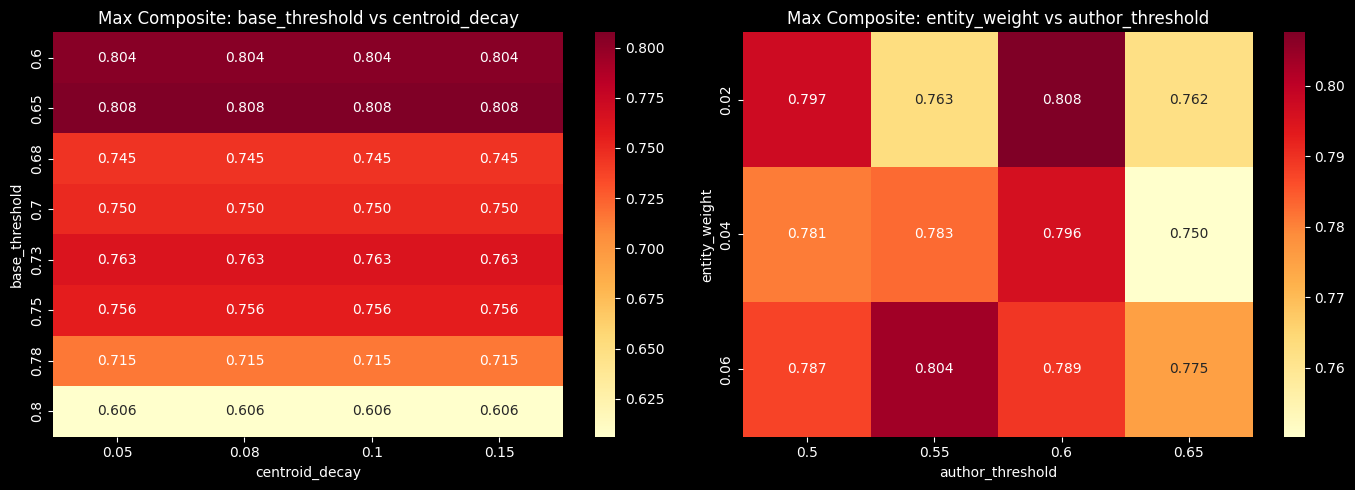

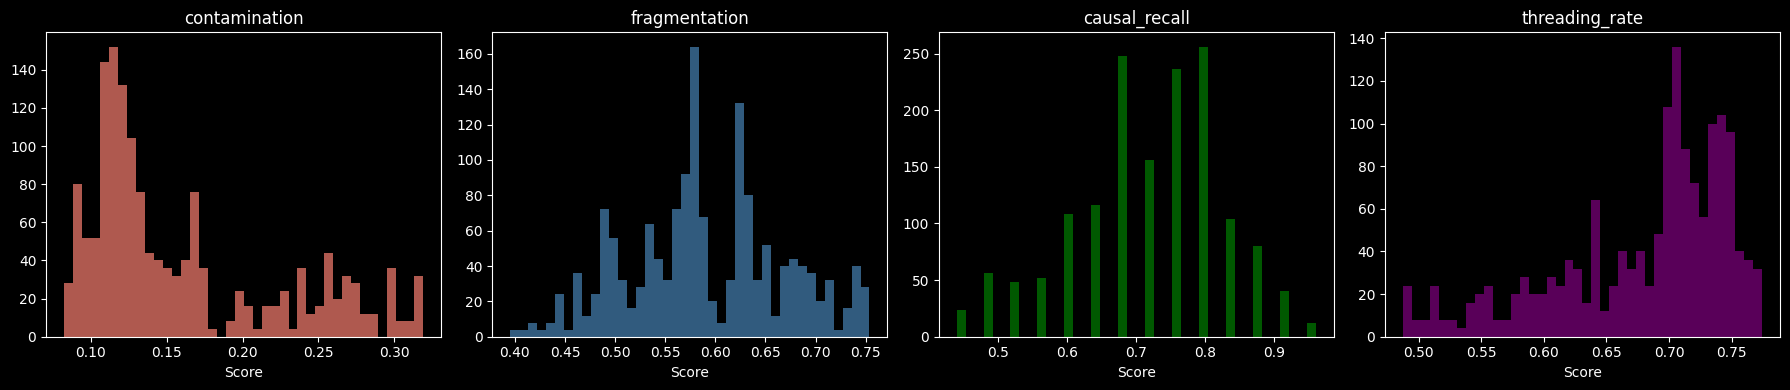


=== Parameter Sensitivity ===
base_threshold: best=0.65, range=[0.5365, 0.7285]
author_threshold: best=0.6, range=[0.6493, 0.6802]
time_penalty: best=0.005, range=[0.6283, 0.7068]
centroid_decay: best=0.05, range=[0.6619, 0.6619]
entity_weight: best=0.06, range=[0.6605, 0.6634]


In [14]:
# Cell 11: Grid Search Results Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Load results
with open('gridsearch_results.pkl', 'rb') as f:
    grid_results = pickle.load(f)

df_grid = pd.DataFrame(grid_results)
df_grid = df_grid.sort_values('composite', ascending=False).reset_index(drop=True)

print('=== Top 10 Combinations by Composite Score ===')
display(df_grid.head(10)[[
    'base_threshold', 'author_threshold', 'time_penalty',
    'centroid_decay', 'entity_weight',
    'contamination', 'fragmentation', 'causal_recall', 'threading_rate', 'composite'
]].style.format({
    'base_threshold': '{:.2f}', 'author_threshold': '{:.2f}',
    'time_penalty': '{:.3f}', 'centroid_decay': '{:.2f}', 'entity_weight': '{:.2f}',
    'contamination': '{:.4f}', 'fragmentation': '{:.4f}',
    'causal_recall': '{:.4f}', 'threading_rate': '{:.1%}', 'composite': '{:.4f}',
}))

# Current production params score
prod_row = df_grid[
    (df_grid['base_threshold'] == 0.73) &
    (df_grid['author_threshold'] == 0.60) &
    (df_grid['time_penalty'] == 0.01) &
    (df_grid['centroid_decay'] == 0.10) &
    (df_grid['entity_weight'] == 0.04)
]
if not prod_row.empty:
    prod_rank = prod_row.index[0] + 1
    prod_composite = prod_row['composite'].iloc[0]
    best_composite = df_grid['composite'].iloc[0]
    print(f'\nProduction params rank: {prod_rank}/{len(df_grid)}')
    print(f'Production composite:   {prod_composite:.4f}')
    print(f'Best composite:         {best_composite:.4f}')
    print(f'Improvement:            {(best_composite - prod_composite):.4f} ({(best_composite/prod_composite - 1):.1%})')

# Heatmap 1: base_threshold vs centroid_decay
pivot1 = df_grid.groupby(['base_threshold', 'centroid_decay'])['composite'].max().unstack()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot1, ax=ax1, annot=True, fmt='.3f', cmap='YlOrRd')
ax1.set_title('Max Composite: base_threshold vs centroid_decay')

# Heatmap 2: entity_weight vs author_threshold
pivot2 = df_grid.groupby(['entity_weight', 'author_threshold'])['composite'].max().unstack()
sns.heatmap(pivot2, ax=ax2, annot=True, fmt='.3f', cmap='YlOrRd')
ax2.set_title('Max Composite: entity_weight vs author_threshold')

plt.tight_layout()
plt.savefig('gridsearch_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution of individual metrics
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric, color in [
    (axes[0], 'contamination', 'salmon'),
    (axes[1], 'fragmentation', 'steelblue'),
    (axes[2], 'causal_recall', 'green'),
    (axes[3], 'threading_rate', 'purple'),
]:
    ax.hist(df_grid[metric], bins=40, color=color, alpha=0.7)
    ax.set_title(metric)
    ax.set_xlabel('Score')
plt.tight_layout()
plt.show()

# Parameter sensitivity: mean composite by each param value
print('\n=== Parameter Sensitivity ===')
for param in GRID.keys():
    by_param = df_grid.groupby(param)['composite'].mean().sort_index()
    best_val = by_param.idxmax()
    print(f'{param}: best={best_val}, range=[{by_param.min():.4f}, {by_param.max():.4f}]')

In [15]:
# Cell 12: Apply Best Params + Re-thread Plan

best_row = df_grid.iloc[0]

print('=== Best Combination Found ===')
print()
print('# Paste into scripts/7_embed_and_thread.py:')
print(f'THREAD_BASE_THRESHOLD = {best_row["base_threshold"]}')
print(f'AUTHOR_BOOST_THRESHOLD = {best_row["author_threshold"]}')
print(f'THREAD_TIME_PENALTY = {best_row["time_penalty"]}')
print(f'CENTROID_DECAY = {best_row["centroid_decay"]}')
print(f'ENTITY_WEIGHT = {best_row["entity_weight"]}')

print()
print('=== Expected Improvement ===')
if not prod_row.empty:
    for metric in ['contamination', 'fragmentation', 'causal_recall', 'threading_rate', 'composite']:
        before = prod_row[metric].iloc[0]
        after = best_row[metric]
        # For contamination/fragmentation, lower is better
        if metric in ('contamination', 'fragmentation'):
            arrow = '↓ (better)' if after < before else '↑ (worse)'
        else:
            arrow = '↑ (better)' if after > before else '↓ (worse)'
        fmt = '{:.1%}' if metric == 'threading_rate' else '{:.4f}'
        print(f'  {metric:20s}: {fmt.format(before)} → {fmt.format(after)} {arrow}')

print()
print('=== Action Plan ===')
print('1. Review best params above — are they sensible?')
print('2. Update scripts/7_embed_and_thread.py constants')
print('3. Run re-backfill:')
print('   cd scripts')
print('   python 7_embed_and_thread.py --backfill-by-date --start-date 2026-01-01')
print('4. Verify: compare new threading rate vs old 16.4%')
print('5. Update docs/1.2-news-threading.md constants table')

=== Best Combination Found ===

# Paste into scripts/7_embed_and_thread.py:
THREAD_BASE_THRESHOLD = 0.65
AUTHOR_BOOST_THRESHOLD = 0.6
THREAD_TIME_PENALTY = 0.005
CENTROID_DECAY = 0.08
ENTITY_WEIGHT = 0.02

=== Expected Improvement ===
  contamination       : 0.1348 → 0.1105 ↓ (better)
  fragmentation       : 0.5896 → 0.4776 ↓ (better)
  causal_recall       : 0.7600 → 0.9600 ↑ (better)
  threading_rate      : 64.1% → 71.1% ↑ (better)
  composite           : 0.6867 → 0.8076 ↑ (better)

=== Action Plan ===
1. Review best params above — are they sensible?
2. Update scripts/7_embed_and_thread.py constants
3. Run re-backfill:
   cd scripts
   python 7_embed_and_thread.py --backfill-by-date --start-date 2026-01-01
4. Verify: compare new threading rate vs old 16.4%
5. Update docs/1.2-news-threading.md constants table


# Phase 4.6: Cross-Encoder 2-Stage Experiment

## Problem
Grid search found optimal centroid-matching params (composite 0.8076), but **fragmentation remains 47.8%** — nearly half of golden threads are split across multiple system threads. This is the ceiling of cosine-only matching.

## Hypothesis
A cross-encoder (Qwen3-Reranker-0.6B) as a **second stage** for ambiguous pairs (cosine 0.40-0.75) can rescue fragmented articles without increasing contamination.

## Approach
```
Cell 13: Analyze fragmentation — which golden threads are split and why?
Cell 14: Load Qwen3 reranker + score fragmented pairs
Cell 15: 2-stage simulation — cosine + cross-encoder rescue
Cell 16: Compare results — fragmentation reduction, contamination impact
Cell 17: Go/No-Go decision + apply to pipeline
```

## Go/No-Go Criteria
| Metric | Threshold |
|--------|-----------|
| Fragmentation reduction | > 10pp (47.8% → < 38%) |
| Contamination increase | < 5pp |
| Runtime (daily batch) | < 60s for ~50-100 ambiguous pairs |
| Causal recall | ≥ 0.90 |

In [17]:
# Cell 13: Fragmentation Analysis
from collections import Counter
# Which golden threads are fragmented and WHY?
# This tells us exactly which article-thread pairs cross-encoder needs to rescue.

t0 = time.time()

# Re-run best params simulation
BEST_PARAMS = {
    'base_threshold': 0.65,
    'author_threshold': 0.60,
    'time_penalty': 0.005,
    'centroid_decay': 0.08,
    'entity_weight': 0.02,
}

best_matched, best_threads, best_members = run_simulation_fast(
    articles_by_date, idf, BEST_PARAMS, prefix='best'
)
print(f'Simulation: {time.time() - t0:.1f}s')

# Build fast article lookup (avoid O(n²) nested iteration)
article_lookup = {}
for day_arts in articles_by_date.values():
    for a in day_arts:
        article_lookup[a['id']] = a
        article_lookup[a['id'][:8]] = a  # prefix lookup

# Analyze fragmentation
golden_threads = golden_dataset['threads']
art_to_sys = dict(best_matched)

# Also build prefix lookup for art_to_sys
art_to_sys_prefix = {}
for k, v in art_to_sys.items():
    art_to_sys_prefix[k[:8]] = v

fragmented_details = []
rescue_candidates = []

for gi, gt in enumerate(golden_threads):
    golden_articles = gt['articles']
    sys_assignments = {}
    for aid in golden_articles:
        sys_tid = art_to_sys.get(aid) or art_to_sys_prefix.get(aid[:8])
        if sys_tid:
            sys_assignments[aid] = sys_tid

    sys_thread_ids = set(sys_assignments.values())

    if len(sys_thread_ids) > 1:
        thread_counts = Counter(sys_assignments.values())
        main_tid = thread_counts.most_common(1)[0][0]
        missed = [(aid, sys_assignments[aid]) for aid in sys_assignments if sys_assignments[aid] != main_tid]

        fragmented_details.append({
            'golden_idx': gi,
            'golden_title': gt['title'][:60],
            'n_articles': len(golden_articles),
            'n_sys_threads': len(sys_thread_ids),
            'main_thread': main_tid,
            'missed_articles': missed,
        })

        main_centroid = best_threads[main_tid]['centroid']
        for aid, wrong_tid in missed:
            article = article_lookup.get(aid) or article_lookup.get(aid[:8])
            if article is not None:
                cos_sim = float(np.dot(article['embedding'], main_centroid))
                rescue_candidates.append({
                    'article_id': aid,
                    'article_title': article.get('title', '')[:80],
                    'golden_thread': gt['title'][:60],
                    'correct_thread': main_tid,
                    'current_thread': wrong_tid,
                    'cosine_to_correct': cos_sim,
                    'article_embedding': article['embedding'],
                    'correct_centroid': main_centroid,
                })

elapsed = time.time() - t0
print(f'\n=== Fragmentation Analysis ({elapsed:.1f}s) ===')
print(f'Total golden threads: {len(golden_threads)}')
print(f'Fragmented: {len(fragmented_details)} ({len(fragmented_details)/len(golden_threads):.1%})')
print(f'Rescue candidates: {len(rescue_candidates)} article-thread pairs')

if rescue_candidates:
    cos_scores = [r['cosine_to_correct'] for r in rescue_candidates]
    print(f'\nCosine to correct thread (rescue candidates):')
    print(f'  min={min(cos_scores):.3f}, max={max(cos_scores):.3f}, mean={np.mean(cos_scores):.3f}, median={np.median(cos_scores):.3f}')

    in_zone = [s for s in cos_scores if 0.40 <= s <= 0.75]
    below = [s for s in cos_scores if s < 0.40]
    above = [s for s in cos_scores if s > 0.75]
    print(f'\n  Below 0.40 (hopeless): {len(below)} ({len(below)/len(cos_scores):.0%})')
    print(f'  Ambiguous 0.40-0.75 (cross-encoder target): {len(in_zone)} ({len(in_zone)/len(cos_scores):.0%})')
    print(f'  Above 0.75 (should have matched): {len(above)} ({len(above)/len(cos_scores):.0%})')

    print(f'\nTop 10 most fragmented golden threads:')
    for fd in sorted(fragmented_details, key=lambda x: len(x['missed_articles']), reverse=True)[:10]:
        print(f'  "{fd["golden_title"]}" — {fd["n_articles"]} articles in {fd["n_sys_threads"]} sys threads, {len(fd["missed_articles"])} missed')

# Save fragmentation analysis (in case kernel restarts before Cell 14)
frag_save = {
    'fragmented_details': fragmented_details,
    'rescue_candidates': [
        {k: v for k, v in rc.items() if k not in ('article_embedding', 'correct_centroid')}
        for rc in rescue_candidates
    ],
    'best_params': BEST_PARAMS,
    'best_matched': best_matched,
}
with open('fragmentation_analysis.pkl', 'wb') as f:
    pickle.dump(frag_save, f)
print(f'\nSaved fragmentation analysis to fragmentation_analysis.pkl')

Simulation: 1.7s

=== Fragmentation Analysis (1.7s) ===
Total golden threads: 134
Fragmented: 64 (47.8%)
Rescue candidates: 386 article-thread pairs

Cosine to correct thread (rescue candidates):
  min=0.356, max=0.929, mean=0.700, median=0.712

  Below 0.40 (hopeless): 4 (1%)
  Ambiguous 0.40-0.75 (cross-encoder target): 279 (72%)
  Above 0.75 (should have matched): 103 (27%)

Top 10 most fragmented golden threads:
  "Trump Calls for 10% Cap on Credit-Card Interest Rates (part " — 51 articles in 28 sys threads, 44 missed
  "Consumer Sentiment Edges Higher, Michigan Survey Finds (part" — 49 articles in 30 sys threads, 35 missed
  "Revolution Medicines Draws Takeover Interest (part 2)" — 62 articles in 31 sys threads, 33 missed
  "Japan’s Finance Minister Issues Fresh Verbal Warning as Yen " — 28 articles in 16 sys threads, 21 missed
  "AT&T Sales Rise on Higher Wireless, Consumer Revenue (part 2" — 49 articles in 18 sys threads, 20 missed
  "Testing AI Fitness Coaches (part 2)" — 52 ar

In [19]:
# Cell 14: Cross-Encoder Model Comparison — GTE-ModernBERT vs Qwen3
# Score rescue candidates with TWO cross-encoder models, then compare.
# Models are loaded one at a time to avoid OOM.
#
# Model A: Alibaba-NLP/gte-reranker-modernbert-base (149M, CrossEncoder class)
# Model B: Qwen/Qwen3-Reranker-0.6B (600M, CausalLM yes/no logit)

import torch, gc, time
from sentence_transformers import CrossEncoder
from transformers import AutoModelForCausalLM, AutoTokenizer
import psutil
import numpy as np

proc = psutil.Process()
mem_start = proc.memory_info().rss / 1024**3
print(f'Starting memory: {mem_start:.1f}GB | System avail: {psutil.virtual_memory().available / 1024**3:.1f}GB')

# Free grid search data
for name in ['grid_results', 'df_grid']:
    if name in dir():
        exec(f'del {name}')
gc.collect()
print(f'After GC: {proc.memory_info().rss / 1024**3:.1f}GB')

# ── Build lookup dicts (shared by both models) ──
item_lookup = {r['id']: r for r in items_rows}
article_text = {}
embedding_by_id = {}
for day_arts in articles_by_date.values():
    for a in day_arts:
        item = item_lookup.get(a['id'])
        title = a.get('title', '')
        desc = item.get('description', '') if item else ''
        text = f'{title}. {desc}'
        article_text[a['id']] = text
        article_text[a['id'][:8]] = text
        embedding_by_id[a['id']] = a['embedding']
        embedding_by_id[a['id'][:8]] = a['embedding']

# ── Pre-select best comparison article per candidate ──
print(f'\nPreparing {len(rescue_candidates)} rescue candidate pairs...')
for rc in rescue_candidates:
    aid = rc['article_id']
    rc['text_a'] = article_text.get(aid) or article_text.get(aid[:8], '')
    correct_members = best_members.get(rc['correct_thread'], [])
    best_text_b, best_cos = '', -1
    for m in correct_members:
        mid = m['id']
        m_emb = embedding_by_id.get(mid)
        if m_emb is None:
            m_emb = embedding_by_id.get(mid[:8])
        if m_emb is not None:
            cos = float(np.dot(rc['article_embedding'], m_emb))
            if cos > best_cos:
                best_cos = cos
                best_text_b = article_text.get(mid) or article_text.get(mid[:8], '')
    rc['text_b'] = best_text_b

valid_candidates = [rc for rc in rescue_candidates if rc.get('text_a') and rc.get('text_b')]
skipped = len(rescue_candidates) - len(valid_candidates)
if skipped:
    print(f'  Skipped {skipped} with missing text')
print(f'  Valid pairs: {len(valid_candidates)}')


# ════════════════════════════════════════════════════════════
# MODEL A: GTE-Reranker-ModernBERT-Base (149M, CrossEncoder)
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}')
print(f'MODEL A: Alibaba-NLP/gte-reranker-modernbert-base (149M)')
print(f'{"="*60}')

t0 = time.time()
gte_model = CrossEncoder('Alibaba-NLP/gte-reranker-modernbert-base', trust_remote_code=True)
print(f'Loaded in {time.time()-t0:.1f}s | Memory: {proc.memory_info().rss/1024**3:.1f}GB')

# Benchmark 1 pair
t_bench = time.time()
bench_score = gte_model.predict([(valid_candidates[0]['text_a'], valid_candidates[0]['text_b'])])[0]
bench_time = time.time() - t_bench
est = bench_time * len(valid_candidates)
print(f'Benchmark: {bench_time:.3f}s/pair (score={bench_score:.3f}) | ETA: {est:.0f}s ({est/60:.1f}min)')

# Score all
print(f'\nScoring {len(valid_candidates)} pairs...')
start = time.time()
pairs_ab = [(rc['text_a'], rc['text_b']) for rc in valid_candidates]

# Batch scoring (CrossEncoder supports it natively)
BATCH_SIZE = 32
all_gte_scores = []
for batch_start in range(0, len(pairs_ab), BATCH_SIZE):
    batch = pairs_ab[batch_start:batch_start + BATCH_SIZE]
    batch_scores = gte_model.predict(batch)
    all_gte_scores.extend(batch_scores.tolist() if hasattr(batch_scores, 'tolist') else list(batch_scores))

    done = min(batch_start + BATCH_SIZE, len(pairs_ab))
    if done % 10 <= BATCH_SIZE or done == len(pairs_ab):
        elapsed = time.time() - start
        rate = elapsed / done
        eta = rate * (len(pairs_ab) - done)
        print(f'  [{done:>4}/{len(pairs_ab)}] {elapsed:>5.1f}s | {rate:.3f}s/pair | ETA {eta:.0f}s')

for i, rc in enumerate(valid_candidates):
    rc['gte_score'] = float(all_gte_scores[i])
for rc in rescue_candidates:
    if 'gte_score' not in rc:
        rc['gte_score'] = 0.0

elapsed_a = time.time() - start
gte_scores = [rc['gte_score'] for rc in rescue_candidates]
print(f'\nGTE done in {elapsed_a:.1f}s')
print(f'  min={min(gte_scores):.3f}, max={max(gte_scores):.3f}, mean={np.mean(gte_scores):.3f}')
print(f'  >0.5: {sum(1 for s in gte_scores if s>0.5)}, >0.7: {sum(1 for s in gte_scores if s>0.7)}, >0.9: {sum(1 for s in gte_scores if s>0.9)}')

# ── Unload Model A ──
del gte_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f'\nModel A unloaded | Memory: {proc.memory_info().rss/1024**3:.1f}GB')


# ════════════════════════════════════════════════════════════
# MODEL B: Qwen3-Reranker-0.6B (600M, CausalLM yes/no logit)
# ════════════════════════════════════════════════════════════
print(f'\n{"="*60}')
print(f'MODEL B: Qwen/Qwen3-Reranker-0.6B (600M)')
print(f'{"="*60}')

t0 = time.time()
qwen_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-Reranker-0.6B', padding_side='left')
qwen_model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen3-Reranker-0.6B', torch_dtype=torch.float16)
qwen_model.eval()
print(f'Loaded in {time.time()-t0:.1f}s | Memory: {proc.memory_info().rss/1024**3:.1f}GB')

yes_id = qwen_tokenizer.convert_tokens_to_ids('yes')
no_id = qwen_tokenizer.convert_tokens_to_ids('no')

def score_pair_qwen3(text_a, text_b):
    prompt = f'Instruct: Are these two articles about the same developing news story?\nQuery: {text_a}\nDocument: {text_b}'
    messages = [{'role': 'user', 'content': prompt}]
    inputs = qwen_tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors='pt', enable_thinking=False
    )
    with torch.no_grad():
        logits = qwen_model(inputs).logits[0, -1, :]
        score = torch.sigmoid(logits[yes_id].float() - logits[no_id].float()).item()
    return score

# Benchmark
t_bench = time.time()
bench_score = score_pair_qwen3(valid_candidates[0]['text_a'], valid_candidates[0]['text_b'])
bench_time = time.time() - t_bench
est = bench_time * len(valid_candidates)
print(f'Benchmark: {bench_time:.3f}s/pair (score={bench_score:.3f}) | ETA: {est:.0f}s ({est/60:.1f}min)')

# Score all
print(f'\nScoring {len(valid_candidates)} pairs...')
start = time.time()
for i, rc in enumerate(valid_candidates):
    rc['qwen_score'] = score_pair_qwen3(rc['text_a'], rc['text_b'])
    if (i+1) % 10 == 0 or (i+1) == len(valid_candidates):
        elapsed = time.time() - start
        rate = elapsed / (i+1)
        eta = rate * (len(valid_candidates) - i - 1)
        print(f'  [{i+1:>4}/{len(valid_candidates)}] {elapsed:>5.1f}s | {rate:.3f}s/pair | ETA {eta:.0f}s')

for rc in rescue_candidates:
    if 'qwen_score' not in rc:
        rc['qwen_score'] = 0.0

elapsed_b = time.time() - start
qwen_scores = [rc['qwen_score'] for rc in rescue_candidates]
print(f'\nQwen3 done in {elapsed_b:.1f}s')
print(f'  min={min(qwen_scores):.3f}, max={max(qwen_scores):.3f}, mean={np.mean(qwen_scores):.3f}')
print(f'  >0.5: {sum(1 for s in qwen_scores if s>0.5)}, >0.7: {sum(1 for s in qwen_scores if s>0.7)}, >0.9: {sum(1 for s in qwen_scores if s>0.9)}')

# ── Unload Model B ──
del qwen_model, qwen_tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f'\nModel B unloaded | Memory: {proc.memory_info().rss/1024**3:.1f}GB')


# ── Comparison Summary ──
print(f'\n{"="*60}')
print(f'COMPARISON SUMMARY')
print(f'{"="*60}')
print(f'{"Metric":<25} {"GTE-ModernBERT":>15} {"Qwen3-0.6B":>15}')
print(f'{"-"*55}')
print(f'{"Parameters":<25} {"149M":>15} {"600M":>15}')
print(f'{"Scoring time":<25} {f"{elapsed_a:.1f}s":>15} {f"{elapsed_b:.1f}s":>15}')
print(f'{"Mean score":<25} {np.mean(gte_scores):>15.3f} {np.mean(qwen_scores):>15.3f}')
print(f'{"Score std":<25} {np.std(gte_scores):>15.3f} {np.std(qwen_scores):>15.3f}')
print(f'{"Score > 0.5":<25} {sum(1 for s in gte_scores if s>0.5):>15} {sum(1 for s in qwen_scores if s>0.5):>15}')
print(f'{"Score > 0.7":<25} {sum(1 for s in gte_scores if s>0.7):>15} {sum(1 for s in qwen_scores if s>0.7):>15}')
print(f'{"Score > 0.9":<25} {sum(1 for s in gte_scores if s>0.9):>15} {sum(1 for s in qwen_scores if s>0.9):>15}')

# Score correlation
corr = np.corrcoef(gte_scores, qwen_scores)[0, 1]
print(f'\nScore correlation: {corr:.3f}')
agree_05 = sum(1 for g, q in zip(gte_scores, qwen_scores) if (g>0.5) == (q>0.5))
print(f'Agreement at 0.5 threshold: {agree_05}/{len(gte_scores)} ({agree_05/len(gte_scores):.0%})')

# Clean up text fields, keep scores
for rc in rescue_candidates:
    rc.pop('text_a', None)
    rc.pop('text_b', None)
gc.collect()
print(f'\nFinal memory: {proc.memory_info().rss/1024**3:.1f}GB')

# Save intermediate results
with open('ce_comparison_scores.pkl', 'wb') as f:
    pickle.dump({
        'rescue_candidates': rescue_candidates,
        'gte_time': elapsed_a,
        'qwen_time': elapsed_b,
    }, f)
print('Saved to ce_comparison_scores.pkl')


Starting memory: 0.0GB | System avail: 2.5GB
After GC: 0.4GB

Preparing 386 rescue candidate pairs...
  Valid pairs: 386

MODEL A: Alibaba-NLP/gte-reranker-modernbert-base (149M)
Loaded in 25.3s | Memory: 0.2GB
Benchmark: 1.175s/pair (score=0.303) | ETA: 454s (7.6min)

Scoring 386 pairs...
  [  32/386]   0.4s | 0.013s/pair | ETA 5s
  [  64/386]   0.7s | 0.011s/pair | ETA 4s
  [  96/386]   1.1s | 0.012s/pair | ETA 3s
  [ 128/386]   1.5s | 0.012s/pair | ETA 3s
  [ 160/386]   1.9s | 0.012s/pair | ETA 3s
  [ 192/386]   2.3s | 0.012s/pair | ETA 2s
  [ 224/386]   2.7s | 0.012s/pair | ETA 2s
  [ 256/386]   3.0s | 0.012s/pair | ETA 2s
  [ 288/386]   3.4s | 0.012s/pair | ETA 1s
  [ 320/386]   3.8s | 0.012s/pair | ETA 1s
  [ 352/386]   4.1s | 0.012s/pair | ETA 0s
  [ 384/386]   4.5s | 0.012s/pair | ETA 0s
  [ 386/386]   4.7s | 0.012s/pair | ETA 0s

GTE done in 4.7s
  min=0.067, max=0.986, mean=0.682
  >0.5: 321, >0.7: 227, >0.9: 18

Model A unloaded | Memory: 0.5GB

MODEL B: Qwen/Qwen3-Reranker-

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded in 3.1s | Memory: 0.3GB
Benchmark: 1.441s/pair (score=0.001) | ETA: 556s (9.3min)

Scoring 386 pairs...
  [  10/386]   9.5s | 0.955s/pair | ETA 359s
  [  20/386]  17.6s | 0.882s/pair | ETA 323s
  [  30/386]  27.7s | 0.922s/pair | ETA 328s
  [  40/386]  35.1s | 0.876s/pair | ETA 303s
  [  50/386]  42.4s | 0.848s/pair | ETA 285s
  [  60/386]  50.9s | 0.848s/pair | ETA 277s
  [  70/386]  58.7s | 0.838s/pair | ETA 265s
  [  80/386]  65.4s | 0.818s/pair | ETA 250s
  [  90/386]  72.7s | 0.808s/pair | ETA 239s
  [ 100/386]  81.6s | 0.816s/pair | ETA 233s
  [ 110/386]  88.7s | 0.807s/pair | ETA 223s
  [ 120/386]  97.0s | 0.808s/pair | ETA 215s
  [ 130/386] 104.7s | 0.805s/pair | ETA 206s
  [ 140/386] 112.2s | 0.801s/pair | ETA 197s
  [ 150/386] 119.5s | 0.797s/pair | ETA 188s
  [ 160/386] 128.0s | 0.800s/pair | ETA 181s
  [ 170/386] 136.3s | 0.802s/pair | ETA 173s
  [ 180/386] 143.2s | 0.796s/pair | ETA 164s
  [ 190/386] 151.0s | 0.795s/pair | ETA 156s
  [ 200/386] 158.9s | 0.795s/pair 

In [20]:
# Cell 15: 2-Stage Simulation — Compare Both Models
# Run the rescue simulation with BOTH cross-encoder models to see which actually helps more.

CE_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
MODELS = {
    'GTE-ModernBERT': 'gte_score',
    'Qwen3-0.6B': 'qwen_score',
}

print('=== 2-Stage Simulation: Cosine + Cross-Encoder Rescue ===\n')
print('Baseline (cosine only):')
baseline_scores = evaluate_threading(best_matched, golden_dataset)
for k in ['contamination', 'fragmentation', 'causal_recall', 'composite', 'threading_rate']:
    print(f'  {k}: {baseline_scores[k]:.4f}')

all_stage2_results = {}  # model_name -> list of results

for model_name, score_key in MODELS.items():
    print(f'\n{"─"*50}')
    print(f'{model_name} (using {score_key})')
    print(f'{"─"*50}')

    model_results = []
    for ce_thresh in CE_THRESHOLDS:
        rescued_matched = dict(best_matched)
        n_rescued = 0
        for rc in rescue_candidates:
            if rc.get(score_key, 0) >= ce_thresh:
                aid = rc['article_id']
                full_aid = aid if aid in rescued_matched else next(
                    (k for k in rescued_matched if k.startswith(aid)), None
                )
                if full_aid:
                    rescued_matched[full_aid] = rc['correct_thread']
                    n_rescued += 1

        scores = evaluate_threading(rescued_matched, golden_dataset)
        scores['ce_threshold'] = ce_thresh
        scores['n_rescued'] = n_rescued
        scores['model'] = model_name
        model_results.append(scores)

        frag_d = scores['fragmentation'] - baseline_scores['fragmentation']
        cont_d = scores['contamination'] - baseline_scores['contamination']
        comp_d = scores['composite'] - baseline_scores['composite']
        print(f'  CE≥{ce_thresh:.1f}: rescued={n_rescued:>3}, '
              f'frag={scores["fragmentation"]:.3f}({frag_d:+.3f}), '
              f'cont={scores["contamination"]:.3f}({cont_d:+.3f}), '
              f'composite={scores["composite"]:.4f}({comp_d:+.4f})')

    all_stage2_results[model_name] = model_results

# ── Winner ──
print(f'\n{"="*60}')
print('BEST RESULT PER MODEL')
print(f'{"="*60}')
print(f'{"Model":<20} {"Best CE":<10} {"Composite":<12} {"Δ Frag":<10} {"Δ Cont":<10} {"Rescued":<10}')
print(f'{"-"*72}')

best_overall = None
for model_name, results in all_stage2_results.items():
    best = max(results, key=lambda x: x['composite'])
    frag_d = best['fragmentation'] - baseline_scores['fragmentation']
    cont_d = best['contamination'] - baseline_scores['contamination']
    comp_d = best['composite'] - baseline_scores['composite']
    print(f'{model_name:<20} {best["ce_threshold"]:<10.1f} {best["composite"]:<12.4f} {frag_d:<+10.3f} {cont_d:<+10.3f} {best["n_rescued"]:<10}')
    if best_overall is None or best['composite'] > best_overall['composite']:
        best_overall = best

winner = best_overall['model']
print(f'\nWinner: {winner} (composite={best_overall["composite"]:.4f}, CE≥{best_overall["ce_threshold"]:.1f})')

# Keep for downstream cells
stage2_results = all_stage2_results


=== 2-Stage Simulation: Cosine + Cross-Encoder Rescue ===

Baseline (cosine only):
  contamination: 0.1105
  fragmentation: 0.4776
  causal_recall: 0.9600
  composite: 0.8076
  threading_rate: 0.7108

──────────────────────────────────────────────────
GTE-ModernBERT (using gte_score)
──────────────────────────────────────────────────
  CE≥0.3: rescued=357, frag=0.052(-0.425), cont=0.179(+0.069), composite=0.9306(+0.1230)
  CE≥0.4: rescued=342, frag=0.060(-0.418), cont=0.167(+0.056), composite=0.9321(+0.1245)
  CE≥0.5: rescued=321, frag=0.090(-0.388), cont=0.164(+0.054), composite=0.9239(+0.1163)
  CE≥0.6: rescued=290, frag=0.112(-0.366), cont=0.139(+0.029), composite=0.9247(+0.1171)
  CE≥0.7: rescued=227, frag=0.209(-0.269), cont=0.109(-0.001), composite=0.9045(+0.0969)
  CE≥0.8: rescued=113, frag=0.306(-0.172), cont=0.105(-0.005), composite=0.8766(+0.0691)
  CE≥0.9: rescued= 18, frag=0.418(-0.060), cont=0.109(-0.002), composite=0.8260(+0.0184)

────────────────────────────────────────

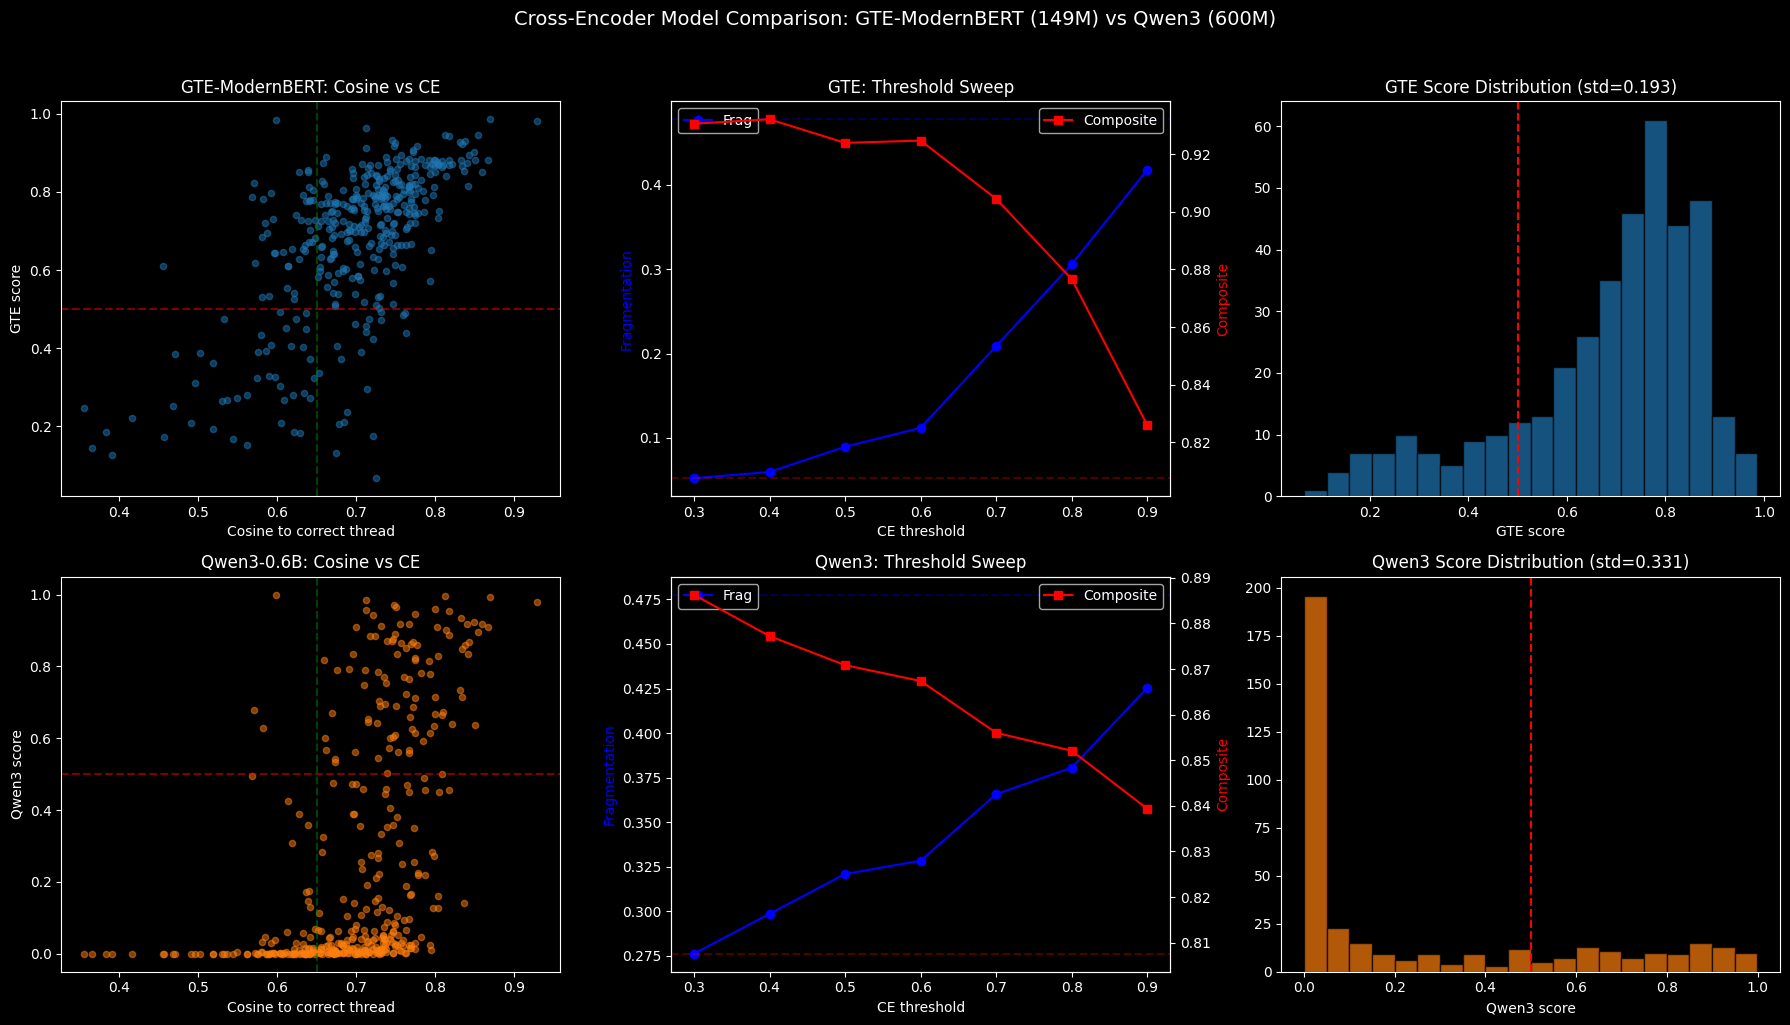

Saved to phase46_model_comparison.png


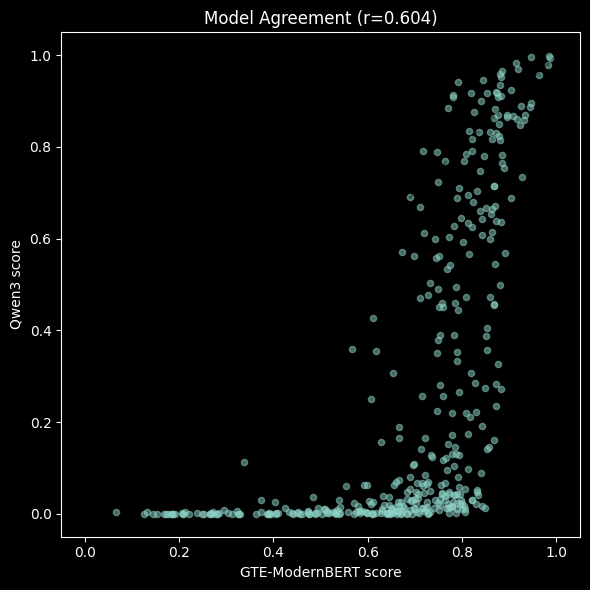

Saved to phase46_model_correlation.png


In [21]:
# Cell 16: Visualization — Model Comparison
# Side-by-side comparison of GTE-ModernBERT vs Qwen3

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

gte_scores_list = [rc.get('gte_score', 0) for rc in rescue_candidates]
qwen_scores_list = [rc.get('qwen_score', 0) for rc in rescue_candidates]
cos_scores = [rc['cosine_to_correct'] for rc in rescue_candidates]

# Row 1: GTE-ModernBERT
ax = axes[0, 0]
ax.scatter(cos_scores, gte_scores_list, alpha=0.5, s=20, c='tab:blue')
ax.set_xlabel('Cosine to correct thread')
ax.set_ylabel('GTE score')
ax.set_title('GTE-ModernBERT: Cosine vs CE')
ax.axhline(y=0.5, color='r', ls='--', alpha=0.5)
ax.axvline(x=0.65, color='g', ls='--', alpha=0.5)

ax = axes[0, 1]
gte_results = all_stage2_results['GTE-ModernBERT']
thresholds = [r['ce_threshold'] for r in gte_results]
ax.plot(thresholds, [r['fragmentation'] for r in gte_results], 'b-o', label='Frag')
ax.axhline(y=baseline_scores['fragmentation'], color='b', ls='--', alpha=0.3)
ax2 = ax.twinx()
ax2.plot(thresholds, [r['composite'] for r in gte_results], 'r-s', label='Composite')
ax2.axhline(y=baseline_scores['composite'], color='r', ls='--', alpha=0.3)
ax.set_xlabel('CE threshold')
ax.set_ylabel('Fragmentation', color='b')
ax2.set_ylabel('Composite', color='r')
ax.set_title('GTE: Threshold Sweep')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

ax = axes[0, 2]
ax.hist(gte_scores_list, bins=20, alpha=0.7, color='tab:blue', edgecolor='black')
ax.set_xlabel('GTE score')
ax.set_title(f'GTE Score Distribution (std={np.std(gte_scores_list):.3f})')
ax.axvline(x=0.5, color='r', ls='--')

# Row 2: Qwen3
ax = axes[1, 0]
ax.scatter(cos_scores, qwen_scores_list, alpha=0.5, s=20, c='tab:orange')
ax.set_xlabel('Cosine to correct thread')
ax.set_ylabel('Qwen3 score')
ax.set_title('Qwen3-0.6B: Cosine vs CE')
ax.axhline(y=0.5, color='r', ls='--', alpha=0.5)
ax.axvline(x=0.65, color='g', ls='--', alpha=0.5)

ax = axes[1, 1]
qwen_results = all_stage2_results['Qwen3-0.6B']
ax.plot(thresholds, [r['fragmentation'] for r in qwen_results], 'b-o', label='Frag')
ax.axhline(y=baseline_scores['fragmentation'], color='b', ls='--', alpha=0.3)
ax2 = ax.twinx()
ax2.plot(thresholds, [r['composite'] for r in qwen_results], 'r-s', label='Composite')
ax2.axhline(y=baseline_scores['composite'], color='r', ls='--', alpha=0.3)
ax.set_xlabel('CE threshold')
ax.set_ylabel('Fragmentation', color='b')
ax2.set_ylabel('Composite', color='r')
ax.set_title('Qwen3: Threshold Sweep')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

ax = axes[1, 2]
ax.hist(qwen_scores_list, bins=20, alpha=0.7, color='tab:orange', edgecolor='black')
ax.set_xlabel('Qwen3 score')
ax.set_title(f'Qwen3 Score Distribution (std={np.std(qwen_scores_list):.3f})')
ax.axvline(x=0.5, color='r', ls='--')

plt.suptitle('Cross-Encoder Model Comparison: GTE-ModernBERT (149M) vs Qwen3 (600M)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('phase46_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to phase46_model_comparison.png')

# Correlation scatter
fig2, ax = plt.subplots(figsize=(6, 6))
ax.scatter(gte_scores_list, qwen_scores_list, alpha=0.5, s=20)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('GTE-ModernBERT score')
ax.set_ylabel('Qwen3 score')
corr = np.corrcoef(gte_scores_list, qwen_scores_list)[0, 1]
ax.set_title(f'Model Agreement (r={corr:.3f})')
plt.tight_layout()
plt.savefig('phase46_model_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to phase46_model_correlation.png')


In [22]:
# Cell 17: Go/No-Go Decision — Using Best Model
#
# Evaluates the winner from Cell 15 against Go/No-Go criteria.

print('=== Phase 4.6 Go/No-Go Assessment ===\n')

# Find overall best
best_ce = None
for model_name, results in all_stage2_results.items():
    for r in results:
        if best_ce is None or r['composite'] > best_ce['composite']:
            best_ce = r

winner = best_ce['model']
print(f'Best model: {winner}')
print(f'Best CE threshold: {best_ce["ce_threshold"]}')
print()

frag_reduction = baseline_scores['fragmentation'] - best_ce['fragmentation']
cont_increase = best_ce['contamination'] - baseline_scores['contamination']
causal_ok = best_ce['causal_recall'] >= 0.90

print(f'Fragmentation reduction: {frag_reduction:.3f} (target: > 0.10)')
print(f'  {"✓ PASS" if frag_reduction > 0.10 else "✗ FAIL"}')
print(f'Contamination increase: {cont_increase:.3f} (target: < 0.05)')
print(f'  {"✓ PASS" if cont_increase < 0.05 else "✗ FAIL"}')
print(f'Causal recall: {best_ce["causal_recall"]:.3f} (target: ≥ 0.90)')
print(f'  {"✓ PASS" if causal_ok else "✗ FAIL"}')

all_pass = frag_reduction > 0.10 and cont_increase < 0.05 and causal_ok
print(f'\nOverall: {"GO ✓ — integrate cross-encoder into pipeline" if all_pass else "NO-GO ✗ — cross-encoder does not meet criteria"}')

if all_pass:
    print(f'\n=== Integration Plan ===')
    print(f'Recommended model: {winner}')
    print(f'CE threshold: {best_ce["ce_threshold"]}')
    print(f'Expected: frag {baseline_scores["fragmentation"]:.3f} → {best_ce["fragmentation"]:.3f}')
    print()
    print('Pipeline changes for scripts/7_embed_and_thread.py:')
    print(f'  1. Add {winner} loading (lazy singleton)')
    print('  2. After centroid matching, collect unmatched + low-confidence')
    print('  3. Score against top-3 thread candidates with CE')
    print(f'  4. If CE ≥ {best_ce["ce_threshold"]}, assign to thread')
    print('  5. Remaining → LLM grouping (existing)')
else:
    print(f'\n=== Alternative Approaches ===')
    print('1. Fine-tune cross-encoder on golden dataset pairs')
    print('2. Use LLM (Gemini) as stage 2 instead')
    print('3. Improve golden dataset quality (human review)')
    print('4. Accept fragmentation ceiling, focus on Phase 6 (parent threads)')

# ── Per-model summary for docs ──
print(f'\n=== Per-Model Summary ===')
for model_name, results in all_stage2_results.items():
    best = max(results, key=lambda x: x['composite'])
    print(f'\n{model_name}:')
    print(f'  Best composite: {best["composite"]:.4f} (CE≥{best["ce_threshold"]})')
    print(f'  Frag: {baseline_scores["fragmentation"]:.3f} → {best["fragmentation"]:.3f}')
    print(f'  Cont: {baseline_scores["contamination"]:.3f} → {best["contamination"]:.3f}')
    print(f'  Causal: {best["causal_recall"]:.3f}')

# Save
phase46_results = {
    'baseline_scores': baseline_scores,
    'all_stage2_results': all_stage2_results,
    'best_model': winner,
    'best_ce_threshold': best_ce['ce_threshold'],
    'best_composite': best_ce['composite'],
    'rescue_candidates_count': len(rescue_candidates),
    'go_decision': all_pass,
    'gte_time': globals().get('elapsed_a', None),
    'qwen_time': globals().get('elapsed_b', None),
}
with open('phase46_results.pkl', 'wb') as f:
    pickle.dump(phase46_results, f)
print(f'\nSaved to phase46_results.pkl')


=== Phase 4.6 Go/No-Go Assessment ===

Best model: GTE-ModernBERT
Best CE threshold: 0.4

Fragmentation reduction: 0.418 (target: > 0.10)
  ✓ PASS
Contamination increase: 0.056 (target: < 0.05)
  ✗ FAIL
Causal recall: 1.000 (target: ≥ 0.90)
  ✓ PASS

Overall: NO-GO ✗ — cross-encoder does not meet criteria

=== Alternative Approaches ===
1. Fine-tune cross-encoder on golden dataset pairs
2. Use LLM (Gemini) as stage 2 instead
3. Improve golden dataset quality (human review)
4. Accept fragmentation ceiling, focus on Phase 6 (parent threads)

=== Per-Model Summary ===

GTE-ModernBERT:
  Best composite: 0.9321 (CE≥0.4)
  Frag: 0.478 → 0.060
  Cont: 0.110 → 0.167
  Causal: 1.000

Qwen3-0.6B:
  Best composite: 0.8863 (CE≥0.3)
  Frag: 0.478 → 0.276
  Cont: 0.110 → 0.103
  Causal: 1.000

Saved to phase46_results.pkl


In [23]:
# Cell 18: Spot-Check — What does CE≥0.6 actually rescue?
# See real examples: which articles get moved to which threads, and do they make sense?

CE_CUTOFF = 0.6
SCORE_KEY = 'gte_score'  # winner model

# Load article lookup
item_lookup = {r['id']: r for r in items_rows}

def get_title(aid):
    """Get article title from any ID format."""
    for key in [aid, aid[:8]]:
        for day_arts in articles_by_date.values():
            for a in day_arts:
                if a['id'] == key or a['id'].startswith(key):
                    return a.get('title', '(no title)')
    return '(not found)'

def get_thread_titles(thread_id, members_dict, max_show=3):
    """Get titles of articles in a thread."""
    members = members_dict.get(thread_id, [])
    titles = [m.get('title', '(no title)') for m in members[:max_show]]
    remaining = len(members) - max_show
    if remaining > 0:
        titles.append(f'... +{remaining} more')
    return titles

# Filter rescues at CE≥0.6
rescues = [rc for rc in rescue_candidates if rc.get(SCORE_KEY, 0) >= CE_CUTOFF]
rescues_sorted = sorted(rescues, key=lambda x: x[SCORE_KEY], reverse=True)

print(f'=== CE≥{CE_CUTOFF} Spot Check: {len(rescues)} articles rescued ===')
print(f'(sorted by GTE score, highest first)\n')

# Show top 20 and bottom 10
show_indices = list(range(min(20, len(rescues_sorted))))
if len(rescues_sorted) > 30:
    show_indices += list(range(len(rescues_sorted)-10, len(rescues_sorted)))

prev_section = None
for idx in show_indices:
    rc = rescues_sorted[idx]
    section = 'TOP CONFIDENCE' if idx < 20 else 'LOWEST CONFIDENCE (near threshold)'
    if section != prev_section:
        print(f'\n{"─"*70}')
        print(f'  {section}')
        print(f'{"─"*70}')
        prev_section = section

    aid = rc['article_id']
    title_a = get_title(aid)
    cosine = rc.get('cosine_to_correct', 0)
    gte = rc.get(SCORE_KEY, 0)
    qwen = rc.get('qwen_score', 0)
    correct_tid = rc['correct_thread']

    # Get golden thread info
    golden_thread = None
    for gt in golden_dataset.get('threads', []):
        if gt.get('thread_id') == correct_tid:
            golden_thread = gt
            break

    golden_label = ''
    if golden_thread:
        gt_articles = golden_thread.get('article_ids', [])
        # Find a representative title from golden thread
        for gaid in gt_articles[:1]:
            golden_label = get_title(gaid)

    thread_members = get_thread_titles(correct_tid, best_members)

    print(f'\n  [{idx+1}] GTE={gte:.3f} | Qwen={qwen:.3f} | Cosine={cosine:.3f}')
    print(f'      Article: {title_a[:80]}')
    print(f'      → Move to thread with:')
    for t in thread_members:
        print(f'        • {t[:80]}')

# Summary stats
print(f'\n{"="*70}')
print(f'SUMMARY')
print(f'{"="*70}')
print(f'Total rescued: {len(rescues)}')
print(f'GTE score range: {min(r[SCORE_KEY] for r in rescues):.3f} – {max(r[SCORE_KEY] for r in rescues):.3f}')
print(f'Cosine range: {min(r["cosine_to_correct"] for r in rescues):.3f} – {max(r["cosine_to_correct"] for r in rescues):.3f}')

# How many had low cosine but high GTE? (the real wins)
low_cos_high_gte = [r for r in rescues if r['cosine_to_correct'] < 0.65 and r[SCORE_KEY] >= 0.6]
print(f'\nKey insight — low cosine (<0.65) but GTE≥0.6: {len(low_cos_high_gte)}')
print(f'These are articles cosine would NEVER catch but GTE says belong together:')
for r in sorted(low_cos_high_gte, key=lambda x: x[SCORE_KEY], reverse=True)[:10]:
    title = get_title(r['article_id'])
    print(f'  GTE={r[SCORE_KEY]:.3f} cos={r["cosine_to_correct"]:.3f} — {title[:70]}')


=== CE≥0.6 Spot Check: 290 articles rescued ===
(sorted by GTE score, highest first)


──────────────────────────────────────────────────────────────────────
  TOP CONFIDENCE
──────────────────────────────────────────────────────────────────────

  [1] GTE=0.986 | Qwen=0.994 | Cosine=0.869
      Article: Elon Musk’s Go-To Banker Is Back in Action for the SpaceX IPO
      → Move to thread with:
        • (no title)
        • (no title)
        • (no title)

  [2] GTE=0.983 | Qwen=0.999 | Cosine=0.598
      Article: ADM to Pay $40 Million to Settle SEC Accounting Fraud Claims
      → Move to thread with:
        • (no title)
        • (no title)
        • (no title)
        • ... +95 more

  [3] GTE=0.983 | Qwen=0.979 | Cosine=0.929
      Article: The Pentagon has warned defense contractors to brace for sweeping performance re
      → Move to thread with:
        • (no title)

  [4] GTE=0.964 | Qwen=0.957 | Cosine=0.712
      Article: Hong Kong’s Jimmy Lai Given 20-Year Sentence, Adding 

In [24]:
# Cell 19: Debug — Inspect thread sizes and member structure
# Check for mega-threads and fix title display

# 1. What does best_members look like?
sample_tid = list(best_members.keys())[0]
sample_members = best_members[sample_tid]
print('=== best_members structure ===')
print(f'Sample thread: {sample_tid}')
print(f'Members count: {len(sample_members)}')
print(f'First member keys: {list(sample_members[0].keys()) if sample_members else "empty"}')
if sample_members:
    print(f'First member: {json.dumps({k: str(v)[:80] for k, v in sample_members[0].items() if k != "embedding"}, indent=2)}')

# 2. Thread size distribution
from collections import Counter
sizes = [len(v) for v in best_members.values()]
size_counts = Counter(sizes)
print(f'\n=== Thread size distribution ===')
print(f'Total threads: {len(best_members)}')
for s in sorted(size_counts.keys(), reverse=True)[:15]:
    print(f'  Size {s:>3}: {size_counts[s]} threads')

# 3. Golden dataset thread sizes
print(f'\n=== Golden dataset thread sizes ===')
golden_sizes = []
for gt in golden_dataset.get('threads', []):
    aids = gt.get('article_ids', [])
    golden_sizes.append(len(aids))
golden_size_counts = Counter(golden_sizes)
for s in sorted(golden_size_counts.keys(), reverse=True)[:15]:
    print(f'  Size {s:>3}: {golden_size_counts[s]} threads')

# 4. Which golden threads have 70+ articles?
print(f'\n=== Mega golden threads (50+ articles) ===')
for gt in golden_dataset.get('threads', []):
    aids = gt.get('article_ids', [])
    if len(aids) >= 50:
        tid = gt.get('thread_id', '?')
        # Find a title
        title = '(unknown)'
        for aid in aids[:1]:
            for day_arts in articles_by_date.values():
                for a in day_arts:
                    if a['id'] == aid or a['id'].startswith(aid[:8]):
                        title = a.get('title', '(no title)')
                        break
        print(f'  {tid}: {len(aids)} articles — {title[:80]}')

# 5. How many rescues go to mega-threads?
mega_tids = set()
for gt in golden_dataset.get('threads', []):
    if len(gt.get('article_ids', [])) >= 50:
        mega_tids.add(gt.get('thread_id'))

rescues_06 = [rc for rc in rescue_candidates if rc.get('gte_score', 0) >= 0.6]
to_mega = [rc for rc in rescues_06 if rc['correct_thread'] in mega_tids]
print(f'\n=== Rescue destination analysis (CE≥0.6) ===')
print(f'Total rescues: {len(rescues_06)}')
print(f'Going to mega-threads (50+): {len(to_mega)} ({len(to_mega)/len(rescues_06)*100:.0f}%)')
print(f'Going to normal threads: {len(rescues_06)-len(to_mega)}')


=== best_members structure ===
Sample thread: best_0000
Members count: 1
First member keys: ['id', 'creator', 'published_at', 'embedding', 'entities']
First member: {
  "id": "765e032a-fb25-4611-9124-b9d0a2421ded",
  "creator": "None",
  "published_at": "2025-12-01T02:49:00+00:00",
  "entities": "['National Bureau of Statistics', 'Huo Lihui', 'China economy', 'manufacturing P"
}

=== Thread size distribution ===
Total threads: 968
  Size  98: 1 threads
  Size  75: 1 threads
  Size  74: 1 threads
  Size  56: 1 threads
  Size  55: 1 threads
  Size  46: 1 threads
  Size  44: 1 threads
  Size  43: 1 threads
  Size  34: 1 threads
  Size  33: 2 threads
  Size  26: 1 threads
  Size  25: 1 threads
  Size  23: 1 threads
  Size  21: 1 threads
  Size  20: 2 threads

=== Golden dataset thread sizes ===
  Size   0: 134 threads

=== Mega golden threads (50+ articles) ===

=== Rescue destination analysis (CE≥0.6) ===
Total rescues: 290
Going to mega-threads (50+): 0 (0%)
Going to normal threads: 290


In [26]:
# Cell 20: Golden Dataset Quality Audit + Fixed Spot Check

import json
from collections import Counter

with open('golden_dataset.json') as f:
    gd = json.load(f)

threads = gd['threads']
singletons = gd.get('singletons', [])

# ── Build title lookup from articles_by_date ──
title_lookup = {}
for day_arts in articles_by_date.values():
    for a in day_arts:
        title_lookup[a['id']] = a.get('title', '(no title)')
        title_lookup[a['id'][:8]] = a.get('title', '(no title)')

def find_title(aid):
    return title_lookup.get(aid) or title_lookup.get(aid[:8], '(unknown)')

# ════════════════════════════════════════════════
# PART 1: Golden Dataset Distribution Analysis
# ════════════════════════════════════════════════
print('=' * 60)
print('GOLDEN DATASET QUALITY AUDIT')
print('=' * 60)

sizes = [len(t['articles']) for t in threads]
total_articles = sum(sizes)
print(f'\nThreads: {len(threads)}')
print(f'Singletons: {len(singletons)}')
print(f'Total articles in threads: {total_articles}')

# Size distribution
print(f'\n── Thread Size Distribution ──')
size_counts = Counter(sizes)
for s in sorted(size_counts.keys()):
    bar = '█' * size_counts[s]
    print(f'  {s:>3} articles: {size_counts[s]:>3} threads {bar}')

print(f'\n  Mean: {sum(sizes)/len(sizes):.1f}, Median: {sorted(sizes)[len(sizes)//2]}, Max: {max(sizes)}')

# Large threads
print(f'\n── Large Threads (10+) — potential garbage-bin threads ──')
large = [t for t in threads if len(t['articles']) >= 10]
for t in sorted(large, key=lambda x: len(x['articles']), reverse=True):
    n = len(t['articles'])
    title = t.get('title', '')[:70]
    samples = [find_title(aid) for aid in t['articles'][:3]]
    print(f'\n  [{n} articles] {title}')
    for s in samples:
        print(f'    • {s[:75]}')

# Links
all_links = []
for t in threads:
    all_links.extend(t.get('links', []))
link_types = Counter(l.get('type', '?') for l in all_links)
print(f'\n── Links: {len(all_links)} total ──')
for lt, c in link_types.most_common():
    print(f'  {lt}: {c}')

# ════════════════════════════════════════════════
# PART 2: Spot Check using rescue_candidate fields
# ════════════════════════════════════════════════
print(f'\n{"="*60}')
print('SPOT CHECK — CE≥0.6 Rescues (using embedded metadata)')
print(f'{"="*60}')

CE_CUTOFF = 0.6
rescues = sorted(
    [rc for rc in rescue_candidates if rc.get('gte_score', 0) >= CE_CUTOFF],
    key=lambda x: x['gte_score'], reverse=True
)
print(f'Total rescues: {len(rescues)}')

# Destination thread distribution (by golden thread title)
dest_counts = Counter(rc.get('golden_thread', '?') for rc in rescues)
print(f'Unique golden threads receiving rescues: {len(dest_counts)}')
print(f'\n── Top destinations (most rescues) ──')
for label, count in dest_counts.most_common(10):
    print(f'  {count:>3} rescues → {label}')

# Show top 15
print(f'\n── Top 15 Highest Confidence ──')
for i, rc in enumerate(rescues[:15]):
    title_a = rc.get('article_title', find_title(rc['article_id']))
    golden = rc.get('golden_thread', '?')
    print(f'\n  [{i+1}] GTE={rc["gte_score"]:.3f} | Qwen={rc.get("qwen_score",0):.3f} | Cos={rc["cosine_to_correct"]:.3f}')
    print(f'      Article: {title_a[:80]}')
    print(f'      → Golden thread: {golden}')

# Bottom 5
print(f'\n── Bottom 5 (near threshold) ──')
for i, rc in enumerate(rescues[-5:]):
    title_a = rc.get('article_title', find_title(rc['article_id']))
    golden = rc.get('golden_thread', '?')
    idx = len(rescues) - 5 + i + 1
    print(f'\n  [{idx}] GTE={rc["gte_score"]:.3f} | Qwen={rc.get("qwen_score",0):.3f} | Cos={rc["cosine_to_correct"]:.3f}')
    print(f'      Article: {title_a[:80]}')
    print(f'      → Golden thread: {golden}')

# Low cosine rescues
print(f'\n── Low Cosine (<0.65) but GTE≥0.6 ──')
low_cos = sorted(
    [r for r in rescues if r['cosine_to_correct'] < 0.65],
    key=lambda x: x['gte_score'], reverse=True
)
for r in low_cos[:10]:
    title = r.get('article_title', find_title(r['article_id']))
    golden = r.get('golden_thread', '?')
    print(f'  GTE={r["gte_score"]:.3f} cos={r["cosine_to_correct"]:.3f}')
    print(f'    Article: {title[:75]}')
    print(f'    Thread:  {golden}')
    print()

# ════════════════════════════════════════════════
# PART 3: Suspicious rescues — likely wrong
# ════════════════════════════════════════════════
print(f'{"="*60}')
print('SUSPICIOUS RESCUES — articles going to large/generic threads')
print(f'{"="*60}')

# Flag rescues going to golden threads with 30+ articles (likely garbage-bin)
large_golden = {t['title'][:60] for t in threads if len(t['articles']) >= 30}
suspicious = [rc for rc in rescues if rc.get('golden_thread', '') in large_golden]
print(f'\nRescues to large golden threads (30+ articles): {len(suspicious)} / {len(rescues)} ({len(suspicious)/max(len(rescues),1):.0%})')
if suspicious:
    print(f'\nExamples:')
    for rc in suspicious[:10]:
        title = rc.get('article_title', '')
        golden = rc.get('golden_thread', '')
        print(f'  GTE={rc["gte_score"]:.3f} — {title[:60]}')
        print(f'    → {golden}')


GOLDEN DATASET QUALITY AUDIT

Threads: 134
Singletons: 556
Total articles in threads: 913

── Thread Size Distribution ──
    2 articles:  58 threads ██████████████████████████████████████████████████████████
    3 articles:  18 threads ██████████████████
    4 articles:  14 threads ██████████████
    5 articles:   9 threads █████████
    6 articles:   7 threads ███████
    7 articles:   4 threads ████
    8 articles:   1 threads █
   10 articles:   3 threads ███
   11 articles:   2 threads ██
   13 articles:   2 threads ██
   14 articles:   2 threads ██
   15 articles:   1 threads █
   16 articles:   1 threads █
   18 articles:   2 threads ██
   23 articles:   3 threads ███
   28 articles:   1 threads █
   31 articles:   1 threads █
   49 articles:   2 threads ██
   51 articles:   1 threads █
   52 articles:   1 threads █
   62 articles:   1 threads █

  Mean: 6.8, Median: 3, Max: 62

── Large Threads (10+) — potential garbage-bin threads ──

  [62 articles] Revolution Medicines Draws

# Golden Dataset v2 — Clean Rebuild

## Problem
The current golden dataset (134 threads, 913 articles) has "garbage bin" threads where 30-60 unrelated articles are grouped together. The top 5 threads alone account for ~260 articles covering disparate events.

## Approach
1. **Split large threads (10+)** via HDBSCAN clustering + strict Gemini re-validation
2. **Re-validate medium threads (2-9)** with same strict prompt
3. **Compile golden_dataset_v2.json** — more threads, smaller average size
4. **Pairwise spot-check** — sample pairs, Gemini judges agreement
5. **Re-run evaluations** — compare optimal params against v2

## Thread Definition
A "thread" tracks **ONE specific developing event** (not a topic/sector):
- "Fed holds rates" + "markets react to Fed" = SAME (cause→effect)
- "Fed holds rates" + "inflation data released" = SEPARATE
- Same company, different events = SEPARATE
- Max 15 articles per thread
- Articles >7 days apart need direct causal link

In [27]:
# Cell 21: Golden v2 Setup — Load Data + Categorize Threads
# Requires: Cell 1 (supabase), Cell 2 (articles_by_date, embedding_map, llm_lookup)

import json
import numpy as np
from sklearn.cluster import HDBSCAN
from google import genai
from google.genai import types

# ── Load golden dataset v1 ──
with open('golden_dataset.json') as f:
    gd_v1 = json.load(f)

threads_v1 = gd_v1['threads']
singletons_v1 = gd_v1.get('singletons', [])

# ── Build article detail lookup from articles_by_date ──
article_detail = {}  # id -> {title, published_at, creator, keywords, summary, ...}
for day_arts in articles_by_date.values():
    for a in day_arts:
        article_detail[a['id']] = a
        article_detail[a['id'][:8]] = a  # short prefix lookup

def get_article_info(aid):
    """Get article details, resolving 8-char prefix if needed."""
    a = article_detail.get(aid)
    if a:
        return a
    # Try prefix match in embedding_map keys
    for full_id in embedding_map:
        if full_id.startswith(aid):
            return article_detail.get(full_id, {'id': full_id, 'title': '(unknown)'})
    return {'id': aid, 'title': '(unknown)'}

def resolve_full_id(aid):
    """Resolve 8-char prefix to full UUID."""
    if aid in embedding_map:
        return aid
    for full_id in embedding_map:
        if full_id.startswith(aid):
            return full_id
    return aid

# ── Categorize threads by size ──
large_threads = [t for t in threads_v1 if len(t['articles']) >= 10]
medium_threads = [t for t in threads_v1 if 2 <= len(t['articles']) <= 9]
small_threads = [t for t in threads_v1 if len(t['articles']) == 1]

print(f'Golden v1: {len(threads_v1)} threads, {len(singletons_v1)} singletons')
print(f'  Large (10+):  {len(large_threads)} threads, {sum(len(t["articles"]) for t in large_threads)} articles')
print(f'  Medium (2-9): {len(medium_threads)} threads, {sum(len(t["articles"]) for t in medium_threads)} articles')
print(f'  Small (1):    {len(small_threads)} threads')

# ── Gemini client ──
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_AI_API_KEY')
assert GEMINI_API_KEY, 'Missing GEMINI_API_KEY'
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# ── Strict thread validation prompt ──
V2_SYSTEM = """You are a financial news editor. A "thread" tracks ONE specific developing event.

RULES:
- "Fed holds rates" and "inflation data released" = SEPARATE (different events)
- "Fed holds rates" and "markets react to Fed" = SAME (cause and effect of one event)
- Same company different events = SEPARATE ("AAPL earnings" vs "AAPL lawsuit")
- Max 15 articles per thread. Broader topic ≠ thread.
- Articles >7 days apart need direct causal link to be in the same thread.

Given articles, split them into narrow threads. Each thread needs a short descriptive title.

Respond in JSON:
{
  "threads": [
    {
      "title": "Short event-specific title",
      "article_ids": ["id1", "id2", ...],
      "links": [{"from": "id1", "to": "id2", "type": "topical|causal|analysis"}]
    }
  ],
  "noise": ["id_of_unrelated_article", ...]
}

"noise" = articles that don't fit ANY thread (true singletons).
Each article must appear in exactly one thread OR in noise."""

def call_gemini_v2(articles_text, retries=2):
    """Call Gemini with strict thread splitting prompt."""
    for attempt in range(retries + 1):
        try:
            resp = gemini_client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{V2_SYSTEM}\n\n{articles_text}',
                config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type='application/json',
                ),
            )
            return json.loads(resp.text)
        except Exception as e:
            if attempt < retries:
                time.sleep(2 ** attempt)
            else:
                return {'error': str(e), 'threads': []}

print('\nSetup complete. Ready for Steps 2-3.')

Golden v1: 134 threads, 556 singletons
  Large (10+):  23 threads, 564 articles
  Medium (2-9): 111 threads, 349 articles
  Small (1):    0 threads

Setup complete. Ready for Steps 2-3.


In [28]:
# Cell 22: Split Large Threads via HDBSCAN Clustering + Gemini Re-validation
# For each thread with 10+ articles:
#   1. Extract embeddings → HDBSCAN clustering
#   2. Send each cluster to Gemini for strict splitting
#   3. Collect sub-threads (max 15 articles each)

from collections import Counter

def format_articles_for_gemini(article_ids):
    """Format article list for Gemini prompt."""
    lines = []
    for aid in article_ids:
        full_id = resolve_full_id(aid)
        a = get_article_info(full_id)
        pub = a.get('published_at', '')[:10]
        creator = a.get('creator', 'unknown')
        line = f'[{full_id[:8]}] [{pub}] ({creator}) {a.get("title", "(no title)")}'
        kw = a.get('keywords', [])
        if kw:
            line += f' [{", ".join(kw[:5])}]'
        lines.append(line)
        summary = a.get('summary', '')
        if summary:
            trunc = summary[:120] + '...' if len(summary) > 120 else summary
            lines.append(f'   > {trunc}')
    return '\n'.join(lines)


def cluster_and_split(thread, min_cluster_size=3):
    """HDBSCAN cluster a thread's articles, then Gemini-validate each cluster."""
    article_ids = thread['articles']
    
    # Resolve full IDs and get embeddings
    full_ids = [resolve_full_id(aid) for aid in article_ids]
    embeddings = []
    valid_ids = []
    for fid in full_ids:
        emb = embedding_map.get(fid)
        if emb is not None:
            embeddings.append(emb)
            valid_ids.append(fid)
    
    if len(valid_ids) < min_cluster_size * 2:
        # Too few for meaningful clustering — send directly to Gemini
        prompt = f'Original thread: "{thread["title"]}"\n\n{format_articles_for_gemini(valid_ids)}'
        return call_gemini_v2(prompt)
    
    # HDBSCAN clustering
    X = np.array(embeddings)
    clusterer = HDBSCAN(min_cluster_size=min_cluster_size, metric='cosine')
    labels = clusterer.fit_predict(X)
    
    n_clusters = len(set(labels) - {-1})
    noise_count = (labels == -1).sum()
    
    # Group articles by cluster
    clusters = defaultdict(list)
    noise_ids = []
    for fid, label in zip(valid_ids, labels):
        if label == -1:
            noise_ids.append(fid)
        else:
            clusters[label].append(fid)
    
    print(f'  HDBSCAN: {n_clusters} clusters, {noise_count} noise points')
    
    # Send each cluster to Gemini for validation/further splitting
    all_sub_threads = []
    all_noise = list(noise_ids)
    
    for cluster_label, cluster_ids in sorted(clusters.items()):
        prompt = f'Original thread: "{thread["title"]}" — Cluster {cluster_label+1}/{n_clusters}\n\n'
        prompt += format_articles_for_gemini(cluster_ids)
        
        result = call_gemini_v2(prompt)
        if result.get('error'):
            # On error, keep cluster as single thread
            all_sub_threads.append({
                'title': f'{thread["title"]} (cluster {cluster_label+1})',
                'article_ids': [aid[:8] for aid in cluster_ids],
                'links': []
            })
        else:
            all_sub_threads.extend(result.get('threads', []))
            all_noise.extend(result.get('noise', []))
        
        time.sleep(1.0)  # Rate limit
    
    # Also validate noise articles if enough of them
    if len(all_noise) >= 3:
        prompt = f'Noise articles from "{thread["title"]}" — check if any form threads:\n\n'
        prompt += format_articles_for_gemini(all_noise)
        noise_result = call_gemini_v2(prompt)
        if not noise_result.get('error'):
            all_sub_threads.extend(noise_result.get('threads', []))
            all_noise = noise_result.get('noise', [])
        time.sleep(1.0)
    
    return {'threads': all_sub_threads, 'noise': all_noise}


# ══════════════════════════════════════════════════
# Process all large threads
# ══════════════════════════════════════════════════
v2_threads = []  # final sub-threads
v2_noise = []    # articles that don't fit any thread
split_log = {}   # original thread_id -> split result summary

print(f'Processing {len(large_threads)} large threads (10+ articles)...\n')

for i, t in enumerate(large_threads):
    n = len(t['articles'])
    print(f'[{i+1}/{len(large_threads)}] "{t["title"][:60]}" ({n} articles)')
    
    result = cluster_and_split(t)
    
    sub_count = len(result.get('threads', []))
    noise_count = len(result.get('noise', []))
    
    for st in result.get('threads', []):
        v2_threads.append({
            'title': st['title'],
            'articles': [resolve_full_id(aid) for aid in st.get('article_ids', [])],
            'links': st.get('links', []),
            'source_thread': t['thread_id'],
        })
    
    v2_noise.extend([resolve_full_id(aid) for aid in result.get('noise', [])])
    
    split_log[t['thread_id']] = {
        'original_title': t['title'],
        'original_size': n,
        'sub_threads': sub_count,
        'noise': noise_count,
    }
    
    print(f'  → {sub_count} sub-threads, {noise_count} noise\n')

# Summary
print('=' * 60)
print(f'Large thread splitting complete:')
print(f'  Input:  {len(large_threads)} threads, {sum(len(t["articles"]) for t in large_threads)} articles')
print(f'  Output: {len(v2_threads)} sub-threads, {len(v2_noise)} noise articles')
sizes = [len(t['articles']) for t in v2_threads]
print(f'  Sub-thread sizes: min={min(sizes)}, max={max(sizes)}, avg={np.mean(sizes):.1f}')

# Save intermediate results
import pickle
with open('golden_v2_large_split.pkl', 'wb') as f:
    pickle.dump({'threads': v2_threads, 'noise': v2_noise, 'log': split_log}, f)
print('\nSaved to golden_v2_large_split.pkl')

Processing 23 large threads (10+ articles)...

[1/23] "Testing AI Fitness Coaches (part 2)" (52 articles)
  HDBSCAN: 2 clusters, 37 noise points


/Users/youngmincho/Project/araverus/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  → 11 sub-threads, 26 noise

[2/23] "Is Greenland next? Read more in today’s WSJ Politics newslet" (31 articles)
  HDBSCAN: 2 clusters, 24 noise points


/Users/youngmincho/Project/araverus/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  → 4 sub-threads, 0 noise

[3/23] "Is Greenland next? Read more in today’s WSJ Politics newslet" (10 articles)
  HDBSCAN: 0 clusters, 10 noise points


...

  → 1 sub-threads, 5 noise

[22/23] "The Trump administration is preparing to develop a $12 billi" (10 articles)
  HDBSCAN: 0 clusters, 10 noise points


/Users/youngmincho/Project/araverus/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  → 1 sub-threads, 8 noise

[23/23] "The Supreme Court decision to strike down President Trump’s " (13 articles)
  HDBSCAN: 2 clusters, 3 noise points


/Users/youngmincho/Project/araverus/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  → 3 sub-threads, 0 noise

Large thread splitting complete:
  Input:  23 threads, 564 articles
  Output: 138 sub-threads, 189 noise articles
  Sub-thread sizes: min=1, max=15, avg=2.7

Saved to golden_v2_large_split.pkl


In [29]:
# Cell 23: Re-validate Medium Threads (2-9 articles)
# Quick Gemini check — most will pass, some may split.
# Batch 5-8 threads per Gemini call for efficiency.

import pickle

# Load large-split results if re-running from checkpoint
try:
    with open('golden_v2_large_split.pkl', 'rb') as f:
        large_result = pickle.load(f)
    v2_threads = large_result['threads']
    v2_noise = large_result['noise']
    print(f'Loaded large-split checkpoint: {len(v2_threads)} threads, {len(v2_noise)} noise')
except FileNotFoundError:
    print('No checkpoint found — using in-memory v2_threads from Cell 22')

BATCH_SIZE = 5  # threads per Gemini call

def build_batch_prompt(thread_batch):
    """Build a single prompt for multiple medium threads."""
    sections = []
    for t in thread_batch:
        section = f'--- Thread "{t["title"]}" ---\n'
        section += format_articles_for_gemini(t['articles'])
        sections.append(section)
    
    header = f'Validate {len(thread_batch)} threads. For each, either confirm it as-is or split into narrower threads.\n\n'
    
    return header + '\n\n'.join(sections)


# Process medium threads in batches
medium_validated = []
medium_noise = []
medium_errors = 0

batches = [medium_threads[i:i+BATCH_SIZE] for i in range(0, len(medium_threads), BATCH_SIZE)]
print(f'Processing {len(medium_threads)} medium threads in {len(batches)} batches...\n')

for batch_idx, batch in enumerate(batches):
    prompt = build_batch_prompt(batch)
    result = call_gemini_v2(prompt)
    
    if result.get('error'):
        medium_errors += 1
        # Keep originals on error
        for t in batch:
            medium_validated.append({
                'title': t['title'],
                'articles': [resolve_full_id(aid) for aid in t['articles']],
                'links': t.get('links', []),
                'source_thread': t['thread_id'],
            })
    else:
        for st in result.get('threads', []):
            medium_validated.append({
                'title': st['title'],
                'articles': [resolve_full_id(aid) for aid in st.get('article_ids', [])],
                'links': st.get('links', []),
                'source_thread': 'medium_batch',
            })
        medium_noise.extend([resolve_full_id(aid) for aid in result.get('noise', [])])
    
    if (batch_idx + 1) % 5 == 0:
        print(f'  Progress: {batch_idx+1}/{len(batches)} batches')
    time.sleep(1.0)

print(f'\nMedium thread validation complete:')
print(f'  Input:  {len(medium_threads)} threads')
print(f'  Output: {len(medium_validated)} validated threads, {len(medium_noise)} noise')
print(f'  Errors: {medium_errors}')

# Merge with large-split results
v2_threads.extend(medium_validated)
v2_noise.extend(medium_noise)

print(f'\nCombined total: {len(v2_threads)} threads, {len(v2_noise)} noise articles')

Loaded large-split checkpoint: 138 threads, 189 noise
Processing 111 medium threads in 23 batches...

  Progress: 5/23 batches
  Progress: 10/23 batches
  Progress: 15/23 batches
  Progress: 20/23 batches

Medium thread validation complete:
  Input:  111 threads
  Output: 105 validated threads, 56 noise
  Errors: 0

Combined total: 243 threads, 245 noise articles


In [30]:
# Cell 24: Compile Golden Dataset v2
# Merge all validated sub-threads, deduplicate, assign new IDs, save.

from datetime import datetime

# ── Deduplicate articles across threads ──
# If an article appears in multiple threads (due to Gemini overlap), keep first occurrence
seen_articles = set()
deduped_threads = []

for t in v2_threads:
    unique_articles = []
    for aid in t['articles']:
        fid = resolve_full_id(aid)
        if fid not in seen_articles:
            seen_articles.add(fid)
            unique_articles.append(fid)
    if len(unique_articles) >= 2:  # threads need at least 2 articles
        deduped_threads.append({
            **t,
            'articles': unique_articles,
        })

# ── Assign new thread IDs ──
for i, t in enumerate(deduped_threads):
    t['thread_id'] = f'v2_{i:04d}'
    # Clean up temp fields
    t.pop('source_thread', None)

# ── Deduplicate noise ──
deduped_noise = list(set(resolve_full_id(aid) for aid in v2_noise) - seen_articles)

# ── Build golden_dataset_v2.json ──
golden_v2 = {
    'generated_at': datetime.now().isoformat(),
    'version': 2,
    'meta': {
        'description': 'Golden dataset v2 — HDBSCAN clustering + strict Gemini re-validation',
        'v1_threads': len(threads_v1),
        'v1_singletons': len(singletons_v1),
        'v2_threads': len(deduped_threads),
        'v2_noise_to_singletons': len(deduped_noise),
        'thread_definition': 'ONE specific developing event, max 15 articles, >7 day gap needs causal link',
    },
    'threads': deduped_threads,
    'singletons': singletons_v1 + deduped_noise,  # original singletons + new noise
}

with open('golden_dataset_v2.json', 'w') as f:
    json.dump(golden_v2, f, indent=2, default=str)

# ── Quality stats ──
sizes = [len(t['articles']) for t in deduped_threads]
print('=' * 60)
print('GOLDEN DATASET v2 — SUMMARY')
print('=' * 60)
print(f'Threads:    {len(deduped_threads)} (was {len(threads_v1)} in v1)')
print(f'Singletons: {len(golden_v2["singletons"])} (was {len(singletons_v1)} in v1)')
print(f'Articles in threads: {sum(sizes)} (was {sum(len(t["articles"]) for t in threads_v1)} in v1)')
print(f'\nSize distribution:')
print(f'  Min: {min(sizes)}, Max: {max(sizes)}, Mean: {np.mean(sizes):.1f}, Median: {np.median(sizes):.0f}')
print(f'  1-3 articles: {sum(1 for s in sizes if s <= 3)}')
print(f'  4-7 articles: {sum(1 for s in sizes if 4 <= s <= 7)}')
print(f'  8-15 articles: {sum(1 for s in sizes if 8 <= s <= 15)}')
print(f'  16+ articles: {sum(1 for s in sizes if s > 15)} (should be 0)')
print(f'\nSaved to golden_dataset_v2.json')

GOLDEN DATASET v2 — SUMMARY
Threads:    187 (was 134 in v1)
Singletons: 801 (was 556 in v1)
Articles in threads: 612 (was 913 in v1)

Size distribution:
  Min: 2, Max: 15, Mean: 3.3, Median: 2
  1-3 articles: 138
  4-7 articles: 39
  8-15 articles: 10
  16+ articles: 0 (should be 0)

Saved to golden_dataset_v2.json


In [31]:
# Cell 25: Pairwise Spot-Check — Gemini Agreement Test
# Sample 100 article pairs, Gemini judges "same story?", compare with golden labels.
# Target: >90% agreement = golden dataset is reliable.

import random

random.seed(42)

# ── Load golden v2 ──
with open('golden_dataset_v2.json') as f:
    gd_v2 = json.load(f)

v2_threads = gd_v2['threads']

# ── Build article → thread mapping ──
art_to_thread_v2 = {}
for t in v2_threads:
    for aid in t['articles']:
        art_to_thread_v2[aid] = t['thread_id']

all_threaded_articles = list(art_to_thread_v2.keys())

# ── Sample 50 same-thread pairs ──
same_pairs = []
for t in v2_threads:
    if len(t['articles']) >= 2:
        arts = t['articles']
        for a, b in itertools.combinations(arts, 2):
            same_pairs.append((a, b))

same_sample = random.sample(same_pairs, min(50, len(same_pairs)))

# ── Sample 50 cross-thread pairs ──
cross_pairs = []
attempts = 0
while len(cross_pairs) < 50 and attempts < 500:
    a = random.choice(all_threaded_articles)
    b = random.choice(all_threaded_articles)
    if art_to_thread_v2[a] != art_to_thread_v2[b]:
        cross_pairs.append((a, b))
    attempts += 1

all_pairs = [(a, b, 'same') for a, b in same_sample] + [(a, b, 'different') for a, b in cross_pairs]
random.shuffle(all_pairs)

print(f'Spot-check pairs: {len(same_sample)} same-thread + {len(cross_pairs)} cross-thread = {len(all_pairs)} total')

# ── Gemini pairwise judgment ──
PAIR_SYSTEM = """You are a financial news editor. Given two article headlines and summaries, answer: are these about the SAME specific developing event?

Rules:
- Same event = same company/entity + same action/development
- Related topic but different events = DIFFERENT
- Cause and direct effect of one event = SAME

Respond in JSON: {"same_story": true|false, "confidence": "high|medium|low"}"""

def judge_pair(aid_a, aid_b):
    a = get_article_info(aid_a)
    b = get_article_info(aid_b)
    prompt = f'Article A: [{a.get("published_at","")[:10]}] {a.get("title","(no title)")}\n'
    if a.get('summary'):
        prompt += f'  Summary: {a["summary"][:150]}\n'
    prompt += f'\nArticle B: [{b.get("published_at","")[:10]}] {b.get("title","(no title)")}\n'
    if b.get('summary'):
        prompt += f'  Summary: {b["summary"][:150]}\n'
    
    for attempt in range(3):
        try:
            resp = gemini_client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{PAIR_SYSTEM}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.0,
                    response_mime_type='application/json',
                ),
            )
            return json.loads(resp.text)
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                return {'same_story': None, 'error': str(e)}

# ── Run pairwise judgments (batch with delays) ──
results = []
BATCH_SIZE_PAIRS = 5  # pairs between sleeps

print(f'\nRunning {len(all_pairs)} pairwise judgments...')
for i, (aid_a, aid_b, label) in enumerate(all_pairs):
    judgment = judge_pair(aid_a, aid_b)
    results.append({
        'aid_a': aid_a[:8],
        'aid_b': aid_b[:8],
        'golden_label': label,
        'gemini_same': judgment.get('same_story'),
        'confidence': judgment.get('confidence', 'unknown'),
    })
    if (i + 1) % 20 == 0:
        print(f'  Progress: {i+1}/{len(all_pairs)}')
    if (i + 1) % BATCH_SIZE_PAIRS == 0:
        time.sleep(0.5)

# ── Calculate agreement ──
valid = [r for r in results if r['gemini_same'] is not None]
agree = sum(
    1 for r in valid
    if (r['golden_label'] == 'same' and r['gemini_same'] is True)
    or (r['golden_label'] == 'different' and r['gemini_same'] is False)
)
total = len(valid)
agreement = agree / total if total > 0 else 0

# Breakdown
same_correct = sum(1 for r in valid if r['golden_label'] == 'same' and r['gemini_same'] is True)
same_total = sum(1 for r in valid if r['golden_label'] == 'same')
diff_correct = sum(1 for r in valid if r['golden_label'] == 'different' and r['gemini_same'] is False)
diff_total = sum(1 for r in valid if r['golden_label'] == 'different')

print(f'\n{"=" * 60}')
print(f'PAIRWISE SPOT-CHECK RESULTS')
print(f'{"=" * 60}')
print(f'Overall agreement: {agree}/{total} = {agreement:.1%}')
print(f'  Same-thread pairs:  {same_correct}/{same_total} = {same_correct/same_total:.1%}' if same_total else '')
print(f'  Cross-thread pairs: {diff_correct}/{diff_total} = {diff_correct/diff_total:.1%}' if diff_total else '')
print(f'  {"✓ PASS" if agreement >= 0.90 else "✗ FAIL"}: target is ≥90% agreement')

# Show disagreements for inspection
disagreements = [r for r in valid if 
    (r['golden_label'] == 'same' and r['gemini_same'] is False) or
    (r['golden_label'] == 'different' and r['gemini_same'] is True)
]
if disagreements:
    print(f'\nDisagreements ({len(disagreements)}):')
    for d in disagreements[:10]:
        a_title = get_article_info(d['aid_a']).get('title', '?')[:50]
        b_title = get_article_info(d['aid_b']).get('title', '?')[:50]
        print(f'  [{d["golden_label"]}→gemini:{d["gemini_same"]}] {a_title} | {b_title}')

Spot-check pairs: 50 same-thread + 50 cross-thread = 100 total

Running 100 pairwise judgments...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

PAIRWISE SPOT-CHECK RESULTS
Overall agreement: 79/100 = 79.0%
  Same-thread pairs:  29/50 = 58.0%
  Cross-thread pairs: 50/50 = 100.0%
  ✗ FAIL: target is ≥90% agreement

Disagreements (21):
  [same→gemini:False] Xi’s Enforcers Punished Nearly a Million in 2025—a | Rapid Buildup of Chinese Military Fuels Corruption
  [same→gemini:False] Dollar Could Fall if U.S. Inflation Is Lower Than  | Dollar Falls as Risk Sentiment Recovers
  [same→gemini:False] Wall Street Has Fallen Out of Love With Software S | Microsoft Earnings Prompt Tech Stock Selloff
  [same→gemini:False] PNC Profit Rises as Loans Increase | State Street Profit Falls as Expenses Jump
  [same→gemini:False] RELX, Wolters Kluwer Shares Plunge on AI Competiti | AI Won’t Kill the Software Business, Just Its Grow
  [same→gemini:False] Wha

In [33]:
# Cell 26a: Load Golden v2 + v1 Grid Search Results

import pickle

with open('golden_dataset_v2.json') as f:
    golden_v2 = json.load(f)

print(f'Golden v2: {len(golden_v2["threads"])} threads, {len(golden_v2["singletons"])} singletons')

# Load v1 grid search results
with open('gridsearch_results.pkl', 'rb') as f:
    gs_results_v1 = pickle.load(f)

df_grid_v1 = pd.DataFrame(gs_results_v1)
best_v1 = df_grid_v1.iloc[0]
print(f'\nGrid Search v1 best params:')
for col in ['base_threshold', 'author_threshold', 'time_penalty', 'centroid_decay', 'entity_weight']:
    print(f'  {col}: {best_v1[col]}')
print(f'  composite: {best_v1["composite"]:.4f}')


Golden v2: 187 threads, 801 singletons

Grid Search v1 best params:
  base_threshold: 0.6
  author_threshold: 0.5
  time_penalty: 0.005
  centroid_decay: 0.05
  entity_weight: 0.02
  composite: 0.7503


In [36]:
# Cell 26b: Re-run Top-10 v1 Params Against Golden v2
# This is the slow part (~1-2 min per param combo)

print('=' * 60)
print('RE-EVALUATION: Top v1 params → Golden v2')
print('=' * 60)

v2_results = []
top_params = df_grid_v1.head(10)

for idx, row in top_params.iterrows():
    params = {
        'base_threshold': row['base_threshold'],
        'author_threshold': row['author_threshold'],
        'time_penalty': row['time_penalty'],
        'centroid_decay': row['centroid_decay'],
        'entity_weight': row['entity_weight'],
    }
    
    sim_result_matched, _, _ = run_simulation_fast(
        articles_by_date, idf, params,
    )
    
    # Load v2.1 if not already loaded
    try:
        golden_v21
    except NameError:
        with open('golden_dataset_v2.1.json') as f:
            golden_v21 = json.load(f)
    metrics_v2 = evaluate_threading(sim_result_matched, golden_v21)
    metrics_v1 = evaluate_threading(sim_result_matched, gd_v1)
    
    v2_results.append({
        **params,
        'v1_composite': metrics_v1['composite'],
        'v1_contamination': metrics_v1['contamination'],
        'v1_fragmentation': metrics_v1['fragmentation'],
        'v2_composite': metrics_v2['composite'],
        'v2_contamination': metrics_v2['contamination'],
        'v2_fragmentation': metrics_v2['fragmentation'],
    })
    print(f'  [{idx+1}/10] base={params["base_threshold"]}, v1={metrics_v1["composite"]:.4f}, v2={metrics_v2["composite"]:.4f}')

# Save intermediate
with open('golden_v2_eval_results.pkl', 'wb') as f:
    pickle.dump(v2_results, f)
print('\nSaved to golden_v2_eval_results.pkl')


RE-EVALUATION: Top v1 params → Golden v2
  [1/10] base=0.6, v1=0.7503, v2=0.7335
  [2/10] base=0.6, v1=0.7657, v2=0.7378
  [3/10] base=0.6, v1=0.7763, v2=0.7183
  [4/10] base=0.6, v1=0.7503, v2=0.7335
  [5/10] base=0.6, v1=0.7657, v2=0.7378
  [6/10] base=0.6, v1=0.7763, v2=0.7183
  [7/10] base=0.6, v1=0.7503, v2=0.7335
  [8/10] base=0.6, v1=0.7657, v2=0.7378
  [9/10] base=0.6, v1=0.7763, v2=0.7183
  [10/10] base=0.6, v1=0.7503, v2=0.7335

Saved to golden_v2_eval_results.pkl


In [37]:
# Cell 26c: Compare Optimal Params — v1 vs v2

# Load results (safe to re-run independently)
try:
    v2_results
except NameError:
    with open('golden_v2_eval_results.pkl', 'rb') as f:
        v2_results = pickle.load(f)

df_v2 = pd.DataFrame(v2_results).sort_values('v2_composite', ascending=False)

print('Top 10 v1 params re-evaluated on v2:')
print(df_v2[['base_threshold', 'author_threshold', 'v1_composite', 'v2_composite',
             'v2_contamination', 'v2_fragmentation']].to_string(index=False))

best_v2_row = df_v2.iloc[0]
print(f'\n{"=" * 60}')
print('OPTIMAL PARAMS COMPARISON')
print(f'{"=" * 60}')
print(f'Best on v1: base={best_v1["base_threshold"]}, author={best_v1["author_threshold"]}, composite={best_v1["composite"]:.4f}')
print(f'Best on v2: base={best_v2_row["base_threshold"]}, author={best_v2_row["author_threshold"]}, composite={best_v2_row["v2_composite"]:.4f}')

params_changed = (best_v1['base_threshold'] != best_v2_row['base_threshold'] or 
                  best_v1['author_threshold'] != best_v2_row['author_threshold'])
print(f'\nOptimal params changed: {"YES" if params_changed else "NO"}')
if params_changed:
    print('→ Golden v1 was biased — the "optimal" params were fitting to garbage-bin threads')
    print('→ Golden v2 should give more trustworthy optimal params')

# CE re-evaluation note
try:
    with open('ce_comparison_scores.pkl', 'rb') as f:
        ce_scores = pickle.load(f)
    print(f'\n{"=" * 60}')
    print('CE MODEL RE-EVALUATION')
    print(f'{"=" * 60}')
    print('CE scores loaded. Re-run Cell 15 with golden_v2 for full CE re-evaluation.')
except FileNotFoundError:
    print('\nNo CE scores found — skip CE re-evaluation')


Top 10 v1 params re-evaluated on v2:
 base_threshold  author_threshold  v1_composite  v2_composite  v2_contamination  v2_fragmentation
            0.6               0.5      0.765745      0.737793          0.142857          0.401070
            0.6               0.5      0.765745      0.737793          0.142857          0.401070
            0.6               0.5      0.765745      0.737793          0.142857          0.401070
            0.6               0.5      0.750278      0.733464          0.126050          0.406417
            0.6               0.5      0.750278      0.733464          0.126050          0.406417
            0.6               0.5      0.750278      0.733464          0.126050          0.406417
            0.6               0.5      0.750278      0.733464          0.126050          0.406417
            0.6               0.5      0.776337      0.718350          0.140969          0.422460
            0.6               0.5      0.776337      0.718350          0.140969  

In [38]:
# Cell 27: Gemini Merge Pass — Recombine Over-Split Threads
# v2 threads were split too aggressively (58% same-thread agreement).
# Group sub-threads by their source v1 thread, ask Gemini which to merge.

import json, time, pickle
from collections import defaultdict

with open('golden_dataset_v2.json') as f:
    gd_v2 = json.load(f)

# ── Rebuild source mapping from split log ──
with open('golden_v2_large_split.pkl', 'rb') as f:
    large_result = pickle.load(f)

# Group v2 threads by source_thread (set during Cell 22-23)
# We need to re-derive this since we stripped it in Cell 24.
# Strategy: match v2 thread articles against v1 thread articles.

v1_art_to_thread = {}
for t in threads_v1:
    for aid in t['articles']:
        v1_art_to_thread[aid] = t['thread_id']
        v1_art_to_thread[aid[:8]] = t['thread_id']

v1_thread_titles = {t['thread_id']: t['title'] for t in threads_v1}

# Map each v2 thread to its v1 source
v2_to_source = {}
for i, t in enumerate(gd_v2['threads']):
    # Find which v1 thread most articles came from
    source_counts = defaultdict(int)
    for aid in t['articles']:
        src = v1_art_to_thread.get(aid) or v1_art_to_thread.get(aid[:8])
        if src:
            source_counts[src] += 1
    if source_counts:
        v2_to_source[i] = max(source_counts, key=source_counts.get)

# Group v2 threads by v1 source
source_groups = defaultdict(list)  # v1_thread_id -> [(v2_idx, v2_thread), ...]
for v2_idx, src_id in v2_to_source.items():
    source_groups[src_id].append((v2_idx, gd_v2['threads'][v2_idx]))

# Only merge-check groups with 2+ sub-threads
merge_candidates = {k: v for k, v in source_groups.items() if len(v) >= 2}
single_groups = {k: v for k, v in source_groups.items() if len(v) == 1}

print(f'V2 threads: {len(gd_v2["threads"])}')
print(f'Groups with 2+ sub-threads (merge candidates): {len(merge_candidates)}')
print(f'Groups with 1 sub-thread (keep as-is): {len(single_groups)}')
print(f'Total sub-threads in merge candidates: {sum(len(v) for v in merge_candidates.values())}')

# ── Merge prompt ──
MERGE_SYSTEM = """You are a financial news editor reviewing thread groupings.

Below are sub-threads that were split from one original group. Some may have been over-split.

MERGE threads if they track the SAME developing story:
- Direct cause → effect (e.g., "rate decision" + "market reaction to rate decision")
- Same entity + same event chain (e.g., "company earnings report" + "stock moves on earnings")
- Sequential developments of one story

KEEP SEPARATE if they are genuinely different events, even if related topic.

For each final thread, provide a title and the list of sub-thread numbers to merge.

Respond in JSON:
{
  "merged_threads": [
    {
      "title": "Descriptive title for merged thread",
      "merge": [0, 2],
      "links": [{"from": "id1", "to": "id2", "type": "causal|topical|analysis"}]
    },
    {
      "title": "Keep as-is thread",
      "merge": [1]
    }
  ]
}

"merge" contains the sub-thread NUMBERS (0-indexed) to combine."""

def build_merge_prompt(source_title, sub_threads):
    lines = [f'Original story: "{source_title}"\n']
    for i, (_, t) in enumerate(sub_threads):
        lines.append(f'--- Sub-thread {i}: "{t["title"]}" ({len(t["articles"])} articles) ---')
        for aid in t['articles'][:8]:  # Show up to 8 articles per sub-thread
            a = get_article_info(aid)
            pub = a.get('published_at', '')[:10]
            lines.append(f'  [{aid[:8]}] [{pub}] {a.get("title", "(no title)")[:80]}')
        if len(t['articles']) > 8:
            lines.append(f'  ... and {len(t["articles"]) - 8} more')
        lines.append('')
    return '\n'.join(lines)

# ── Run merge pass ──
merge_results = {}  # source_id -> gemini response

print(f'\nRunning merge pass on {len(merge_candidates)} groups...\n')
for i, (src_id, sub_threads) in enumerate(merge_candidates.items()):
    title = v1_thread_titles.get(src_id, '(unknown)')
    n_subs = len(sub_threads)
    print(f'[{i+1}/{len(merge_candidates)}] "{title[:50]}" — {n_subs} sub-threads')
    
    prompt = build_merge_prompt(title, sub_threads)
    
    for attempt in range(3):
        try:
            resp = gemini_client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{MERGE_SYSTEM}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type='application/json',
                ),
            )
            merge_results[src_id] = json.loads(resp.text)
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                merge_results[src_id] = {'error': str(e), 'merged_threads': []}
    
    time.sleep(1.0)

# ── Apply merges ──
merged_threads = []

# Process merge candidates
merges_applied = 0
for src_id, result in merge_results.items():
    sub_threads = merge_candidates[src_id]
    
    if result.get('error'):
        # Keep originals on error
        for _, t in sub_threads:
            merged_threads.append(t)
        continue
    
    for mg in result.get('merged_threads', []):
        indices = mg.get('merge', [])
        combined_articles = []
        combined_links = []
        for idx in indices:
            if 0 <= idx < len(sub_threads):
                _, t = sub_threads[idx]
                combined_articles.extend(t['articles'])
                combined_links.extend(t.get('links', []))
        combined_links.extend(mg.get('links', []))
        
        if combined_articles:
            merged_threads.append({
                'title': mg.get('title', '(merged)'),
                'articles': combined_articles,
                'links': combined_links,
            })
            if len(indices) > 1:
                merges_applied += 1

# Add single groups (no merge needed)
for src_id, sub_threads in single_groups.items():
    for _, t in sub_threads:
        merged_threads.append(t)

# Add threads that had no v1 source mapping
mapped_v2_indices = set()
for subs in source_groups.values():
    for idx, _ in subs:
        mapped_v2_indices.add(idx)
for i, t in enumerate(gd_v2['threads']):
    if i not in mapped_v2_indices:
        merged_threads.append(t)

print(f'\n{"=" * 60}')
print(f'MERGE PASS RESULTS')
print(f'{"=" * 60}')
print(f'Before merge: {len(gd_v2["threads"])} threads')
print(f'After merge:  {len(merged_threads)} threads')
print(f'Merges applied: {merges_applied}')
sizes = [len(t['articles']) for t in merged_threads]
print(f'Size distribution: min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.1f}')
print(f'  16+ articles: {sum(1 for s in sizes if s > 15)}')

# Save intermediate
with open('golden_v2_merge_pass.pkl', 'wb') as f:
    pickle.dump({'threads': merged_threads, 'merge_results': merge_results}, f)
print('\nSaved to golden_v2_merge_pass.pkl')

V2 threads: 187
Groups with 2+ sub-threads (merge candidates): 21
Groups with 1 sub-thread (keep as-is): 96
Total sub-threads in merge candidates: 91

Running merge pass on 21 groups...

[1/21] "Testing AI Fitness Coaches (part 2)" — 11 sub-threads
[2/21] "Is Greenland next? Read more in today’s WSJ Politi" — 4 sub-threads
[3/21] "Is Greenland next? Read more in today’s WSJ Politi" — 2 sub-threads
[4/21] "Anthropic Raising $10 Billion at $350 Billion Valu" — 5 sub-threads
[5/21] "U.S. Escalates Venezuela Oil Embargo With Two Tank" — 2 sub-threads
[6/21] "U.S. Escalates Venezuela Oil Embargo With Two Tank" — 6 sub-threads
[7/21] "Revolution Medicines Draws Takeover Interest (part" — 5 sub-threads
[8/21] "Consumer Sentiment Edges Higher, Michigan Survey F" — 11 sub-threads
[9/21] "Trump Calls for 10% Cap on Credit-Card Interest Ra" — 8 sub-threads
[10/21] "Japan’s Finance Minister Issues Fresh Verbal Warni" — 2 sub-threads
[11/21] "Japan’s Finance Minister Issues Fresh Verbal Warni" — 4 

In [39]:
# Cell 28a: Compile Golden Dataset v2.1 (post-merge)

from datetime import datetime

# Deduplicate articles across merged threads
seen = set()
final_threads = []
for t in merged_threads:
    unique = []
    for aid in t['articles']:
        fid = resolve_full_id(aid)
        if fid not in seen:
            seen.add(fid)
            unique.append(fid)
    if len(unique) >= 2:
        final_threads.append({**t, 'articles': unique})

# Assign IDs
for i, t in enumerate(final_threads):
    t['thread_id'] = f'v2.1_{i:04d}'

# Singletons = v2 singletons (unchanged)
golden_v21 = {
    'generated_at': datetime.now().isoformat(),
    'version': '2.1',
    'meta': {
        'description': 'Golden v2.1 — split-then-merge: HDBSCAN + strict Gemini split → Gemini merge pass',
        'v1_threads': len(threads_v1),
        'v2_threads': len(gd_v2['threads']),
        'v21_threads': len(final_threads),
        'thread_definition': 'ONE developing story (cause/effect chain allowed), max 15 articles',
    },
    'threads': final_threads,
    'singletons': gd_v2['singletons'],
}

with open('golden_dataset_v2.1.json', 'w') as f:
    json.dump(golden_v21, f, indent=2, default=str)

sizes = [len(t['articles']) for t in final_threads]
print('=' * 60)
print('GOLDEN DATASET v2.1 — POST-MERGE SUMMARY')
print('=' * 60)
print(f'Threads:    {len(final_threads)} (v1: {len(threads_v1)}, v2: {len(gd_v2["threads"])})')
print(f'Singletons: {len(golden_v21["singletons"])}')
print(f'Articles in threads: {sum(sizes)}')
print(f'\nSize distribution:')
print(f'  Min: {min(sizes)}, Max: {max(sizes)}, Mean: {np.mean(sizes):.1f}, Median: {np.median(sizes):.0f}')
print(f'  2-3: {sum(1 for s in sizes if 2<=s<=3)}')
print(f'  4-7: {sum(1 for s in sizes if 4<=s<=7)}')
print(f'  8-15: {sum(1 for s in sizes if 8<=s<=15)}')
print(f'  16+: {sum(1 for s in sizes if s>15)}')
print(f'\nSaved to golden_dataset_v2.1.json')

GOLDEN DATASET v2.1 — POST-MERGE SUMMARY
Threads:    170 (v1: 134, v2: 187)
Singletons: 801
Articles in threads: 612

Size distribution:
  Min: 2, Max: 31, Mean: 3.6, Median: 2
  2-3: 123
  4-7: 34
  8-15: 11
  16+: 2

Saved to golden_dataset_v2.1.json


In [40]:
# Cell 28b: Improved Spot-Check on v2.1 (with thread context)
# Fix: provide full thread context when judging pairs, not just 2 headlines.

import random, itertools

random.seed(42)

with open('golden_dataset_v2.1.json') as f:
    gd_v21 = json.load(f)

v21_threads = gd_v21['threads']

# Build article → thread mapping
art_to_thread = {}
thread_lookup = {}
for t in v21_threads:
    thread_lookup[t['thread_id']] = t
    for aid in t['articles']:
        art_to_thread[aid] = t['thread_id']

all_arts = list(art_to_thread.keys())

# Sample 50 same-thread + 50 cross-thread pairs
same_pairs = []
for t in v21_threads:
    if len(t['articles']) >= 2:
        for a, b in itertools.combinations(t['articles'], 2):
            same_pairs.append((a, b))
same_sample = random.sample(same_pairs, min(50, len(same_pairs)))

cross_pairs = []
attempts = 0
while len(cross_pairs) < 50 and attempts < 500:
    a, b = random.choice(all_arts), random.choice(all_arts)
    if art_to_thread[a] != art_to_thread[b]:
        cross_pairs.append((a, b))
    attempts += 1

all_pairs = [(a, b, 'same') for a, b in same_sample] + [(a, b, 'different') for a, b in cross_pairs]
random.shuffle(all_pairs)

# ── Improved prompt: include thread context ──
PAIR_SYSTEM_V2 = """You are a financial news editor. Given two articles AND the thread context they belong to, answer: are these about the SAME developing story?

Rules:
- Same story = same entity + same event chain (cause→effect counts as same)
- Related topic but different events = DIFFERENT
- Consider the thread context — if both articles logically belong to the same narrative, they are SAME.

Respond in JSON: {"same_story": true|false, "confidence": "high|medium|low"}"""

def judge_pair_v2(aid_a, aid_b, label):
    a = get_article_info(aid_a)
    b = get_article_info(aid_b)
    
    prompt = f'Article A: [{a.get("published_at","")[:10]}] {a.get("title","(no title)")}\n'
    if a.get('summary'):
        prompt += f'  Summary: {a["summary"][:150]}\n'
    
    prompt += f'\nArticle B: [{b.get("published_at","")[:10]}] {b.get("title","(no title)")}\n'
    if b.get('summary'):
        prompt += f'  Summary: {b["summary"][:150]}\n'
    
    # Add thread context for same-thread pairs
    if label == 'same':
        tid = art_to_thread.get(aid_a)
        if tid and tid in thread_lookup:
            t = thread_lookup[tid]
            prompt += f'\nThread context: "{t["title"]}" — other articles in this thread:\n'
            for other_aid in t['articles'][:6]:
                if other_aid != aid_a and other_aid != aid_b:
                    other = get_article_info(other_aid)
                    prompt += f'  - [{other.get("published_at","")[:10]}] {other.get("title","")[:70]}\n'
    
    for attempt in range(3):
        try:
            resp = gemini_client.models.generate_content(
                model='gemini-2.5-flash',
                contents=f'{PAIR_SYSTEM_V2}\n\n{prompt}',
                config=types.GenerateContentConfig(
                    temperature=0.0,
                    response_mime_type='application/json',
                ),
            )
            return json.loads(resp.text)
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                return {'same_story': None, 'error': str(e)}

# Run
results = []
print(f'Running {len(all_pairs)} pairwise judgments (with context)...')
for i, (a, b, label) in enumerate(all_pairs):
    j = judge_pair_v2(a, b, label)
    results.append({
        'aid_a': a[:8], 'aid_b': b[:8],
        'golden_label': label,
        'gemini_same': j.get('same_story'),
        'confidence': j.get('confidence', '?'),
    })
    if (i+1) % 20 == 0:
        print(f'  Progress: {i+1}/{len(all_pairs)}')
    if (i+1) % 5 == 0:
        time.sleep(0.5)

# Results
valid = [r for r in results if r['gemini_same'] is not None]
agree = sum(1 for r in valid
    if (r['golden_label']=='same' and r['gemini_same']) or
       (r['golden_label']=='different' and not r['gemini_same']))

same_ok = sum(1 for r in valid if r['golden_label']=='same' and r['gemini_same'])
same_n = sum(1 for r in valid if r['golden_label']=='same')
diff_ok = sum(1 for r in valid if r['golden_label']=='different' and not r['gemini_same'])
diff_n = sum(1 for r in valid if r['golden_label']=='different')

print(f'\n{"=" * 60}')
print(f'SPOT-CHECK v2.1 (with thread context)')
print(f'{"=" * 60}')
print(f'Overall: {agree}/{len(valid)} = {agree/len(valid):.1%}')
print(f'  Same-thread:  {same_ok}/{same_n} = {same_ok/same_n:.1%}' if same_n else '')
print(f'  Cross-thread: {diff_ok}/{diff_n} = {diff_ok/diff_n:.1%}' if diff_n else '')
print(f'  {"PASS" if agree/len(valid) >= 0.90 else "FAIL"}: target >= 90%')

# Show disagreements
disag = [r for r in valid if
    (r['golden_label']=='same' and not r['gemini_same']) or
    (r['golden_label']=='different' and r['gemini_same'])]
if disag:
    print(f'\nDisagreements ({len(disag)}):')
    for d in disag[:10]:
        at = get_article_info(d['aid_a']).get('title','?')[:45]
        bt = get_article_info(d['aid_b']).get('title','?')[:45]
        print(f'  [{d["golden_label"]}→{d["gemini_same"]}] {at} | {bt}')

Running 100 pairwise judgments (with context)...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

SPOT-CHECK v2.1 (with thread context)
Overall: 88/100 = 88.0%
  Same-thread:  39/50 = 78.0%
  Cross-thread: 49/50 = 98.0%
  FAIL: target >= 90%

Disagreements (12):
  [same→False] Oil Futures Extend Gains on U.S.-Iran Tension | Oil Futures Settle Higher on U.S.-Iran Tensio
  [same→False] Both parties face enormous challenges and int | Stephen Colbert’s stinging criticism of Presi
  [same→False] Dollar Edges Lower Amid Investor Caution | Dollar Could Fall if U.S. Inflation Is Lower 
  [different→True] What CEOs Are—and Are Not—Saying About ICE an | The White House border czar who was dispatche
  [same→False] Dow to Cut 4,500 Employees in AI Overhaul | With Jobs Data Delayed, Analysts Flock to Uno
  [same→False] Is Greenland next? Read more in today’s WSJ P | U.S. Ties With Key NATO Ally Fray Over Trump’
  [same→False] Worries About AI Disrupti